# `econ_anlys_petrol_plus.ipynb` — Oil & Gas Energy Sector (OES) Index Construction

> **File:** `econ_anlys_petrol_plus.ipynb`
> **Purpose:** Analyze the composition of the U.S. Oil & Gas Energy Sector, construct two median-market-cap-weighted indices, compare them using a full causal and statistical toolkit, and persist the OES (Top) index for downstream analysis.
> **Programmer:** Nicholas J. George  |  **Initial Development:** 04/08/2026

---

## Overview

This notebook is the second stage of the multi-part COVID-19 economic impact project. It consumes the Oil & Gas company metadata produced by `econ_anlys_etl.ipynb` and performs two major tasks: a descriptive analysis of how market capitalization is distributed across the six Oil & Gas sub-industries, and the construction and rigorous comparison of two median-market-cap-weighted sector indices. The OES (Top) index — the more tractable six-company benchmark — is then merged with the petroleum price data and persisted as `petrol_plus.json` for consumption by the downstream economic analysis notebooks.

---

## Dependencies

| Library | Role |
|---|---|
| `assetx` | Company data loading, geographic DataFrame construction, index calculation |
| `dtypesx` | Percentage change computation |
| `logx` | Logging and program lifecycle management |
| `mapx` | Interactive Folium geographic world maps |
| `mathx` | Stationarity correction, polynomial degree selection, Granger causality, VAR/VECM, rolling window and minimum period optimization, lag correlation |
| `matplotlibx` | All chart rendering (pie, box, line, scatter, rolling correlation, CV error curves) |
| `pandasx` | Formatted table display and correlation matrices |
| `pandas` | Core data structures |

---

## Outputs

| Config Key | Contents |
|---|---|
| `petrol_plus` | Petroleum prices merged with OES (Top) index daily prices (JSON) |

---

## Index Construction Methodology

Both indices use the same **median-market-cap weighting** scheme. Each company's weight is its median market capitalization divided by the total median market capitalization of the relevant company pool. Daily index prices are the weighted sum of each constituent's daily closing prices, computed via `assetx.rtn_sctr_mrkt_idx_file()`.

The median is chosen over the mean as the weighting basis because it is more robust to the extreme size disparity between large integrated producers and small E&P companies — a choice substantiated empirically by the IQR-based summary statistics in Sections 1.2 and 1.3.

| Index | Company Pool | Constituents |
|---|---|---|
| **OES (All)** | All Oil & Gas sector companies | Each company weighted by its median market cap ÷ total sector median market cap |
| **OES (Top)** | One company per sub-industry — the highest median market cap in each group | Six companies weighted by their median market cap ÷ total top-company median market cap |

The six OES (Top) constituents are identified via `groupby().max()` on the `median_market_cap` column. Their geographic locations, and those of all 220 sector companies, are visualized on interactive Folium world maps (Figures 2.1.1 and 2.3.1).

---

## Part 1: Oil & Gas Energy Sector (OES) Analysis

**Section 1.1** loads the company metadata file and computes industry-level aggregations across all seven market capitalization statistics (count, min, max, mean, median, STD, SEM), displayed in a summary table (Table 1.1.2) and a company-count pie chart (Figure 1.1.1) alongside six market-cap distribution pie charts by statistic (Figure 1.1.2).

**Section 1.2** examines the within-industry spread of mean market capitalizations using IQR-based summary statistics (lower/upper quartile, IQR range, boundary values, mean, median) and a box plot (Figure 1.2).

**Section 1.3** repeats the same IQR analysis for median market capitalizations (Table 1.3, Figure 1.3), directly motivating the choice of median rather than mean as the weighting basis for index construction.

---

## Part 2: OES Index Construction and Comparison

Sections 2.1–2.4 construct and display each index in both absolute price (USD) and daily percentage change form, each with a formatted data table and a time-series line chart. Geographic locations of each company pool are displayed on interactive Folium maps (Figures 2.1.1 and 2.3.1).

**Sections 2.5 and 2.6** provide a rigorous side-by-side comparison of the two indices in absolute price and percentage-change terms respectively. Each comparison applies a ten-step analytical workflow:

**1. Data Table and Pre-Transformation Chart** — The aligned bivariate DataFrame is displayed (Tables 2.5.1, 2.6.1) and plotted as a dual-series line chart before stationarity correction (Figures 2.5.1, 2.6.1).

**2. Stationarity Correction** — `mathx.crct_stnry_df()` applies ADF/KPSS-diagnosed transformations, with a post-transformation chart confirming the corrected series (Figures 2.5.2, 2.6.2).

**3. CV-Selected Polynomial Degree** — `mathx.best_poly_degree()` uses K-Fold cross-validation and AIC to select the optimal regression degree, with the overfitting score table (Tables 2.5.2, 2.6.2) and CV error curve (Figures 2.5.3, 2.6.3) displayed for transparency.

**4. Correlation Matrix** — The optimal correlation method (Pearson, Spearman, or Kendall) is selected via `mathx.find_opt_corr_method()` and the full correlation matrix is displayed (Tables 2.5.3, 2.6.3).

**5. Scatter Plot** — A scatter plot with the CV-selected polynomial regression overlay is rendered (Figures 2.5.4, 2.6.4).

**6. Bidirectional Granger Causality** — `mathx.find_optimal_granger_method()` and `mathx.find_optimal_granger_lag()` select the method and lag empirically via walk-forward cross-validation. Both directions are tested: OES (Top) → OES (All) (Tables 2.5.4, 2.6.4) and OES (All) → OES (Top) (Tables 2.5.5, 2.6.5), with p-value rows highlighted by high, median, and low.

**7. VAR/VECM Model** — `mathx.fit_var_or_vecm()` automatically selects VAR or VECM based on stationarity and cointegration rank, with the full conclusion logged to console and file.

**8. Impulse Response Functions (IRF)** — IRF results are displayed (Tables 2.5.6, 2.6.6) with min, max, and median cell highlighting. If the model is VECM and IRF is unavailable, the table is gracefully skipped with a logged message.

**9. Forecast Error Variance Decomposition (FEVD)** — FEVD results are displayed (Tables 2.5.7/2.5.6, 2.6.7/2.6.6 depending on IRF availability) with the same highlighting scheme, showing what fraction of each index's forecast variance is attributable to shocks from the other.

**10. Rolling Correlation and Lag Correlation** — CV-optimized rolling window (Figures 2.5.5, 2.6.5) and minimum period (Figures 2.5.6, 2.6.6) are selected via `mathx.find_optimal_rolling_window()` and `mathx.find_optimal_min_periods()`. The rolling correlation chart (Figures 2.5.7, 2.6.7) shows how the relationship between the two indices evolved over the 2020–2022 period. The lag correlation chart (Figures 2.5.8, 2.6.8) shows the peak delayed correlation using a horizon derived from the VAR/VECM lag and Granger lag via `mathx.find_optimal_lag_corr_max_lag()`.

**Section 2.7** merges the OES (Top) index into the petroleum prices DataFrame and saves the combined file as `petrol_plus.json` for use in the downstream economic analysis notebooks.

---

## Known Issues

The table number for the FEVD output is determined conditionally at runtime based on whether the IRF table was successfully rendered: if IRF succeeded it is Table 2.5.7 / 2.6.7; if IRF was skipped it reuses 2.5.6 / 2.6.6. This means the FEVD table number is not stable across runs with different model selections, which can cause numbering inconsistencies in the rendered notebook.


In [1]:
 #*******************************************************************************************
 #
 #  File Name:  econ_anlys_petrol_plus.ipynb
 #
 #  File Description:
 #      This interactive Python notebook, econ_anlys_petrol_plus.ipynb, constructs a oil
 #      energy sector index from the median daily market capitalizations of the top oil
 #      company in each industry in the Oil & Gas Energy Sector and, with other oil energy
 #      sector time series, creates the petrol_plus.json file.
 #      
 #
 #  Date            Description                             Programmer
 #  ----------      ------------------------------------    ------------------
 #  04/08/2026      Initial Development                     Nicholas J. George
 #
 #******************************************************************************************/

import assetx
import dtypesx
import logx
import mapx
import mathx
import matplotlibx
import pandasx

import pandas as pd

In [2]:
CONSTANT_LOCAL_FILE_NAME = 'econ_anlys_petrol_plus.ipynb'

In [3]:
logx.set_log_mode(False)

logx.set_image_mode(False)


logx.begin_program('econ_anlys_petrol_plus')

# <br> **Part 1: Oil & Gas Energy Sector (OES) Analysis**

## **Section 1.1: OES By Industry Share Comparison**

### **Read Oil Industry Data from File into DataFrame**

In [4]:
title = 'Table 1.1.1: U.S. Oil Energy Sector Companies'

fmt_dict \
    = {'longitude':         pandasx.fmt_dict['flt'],
       'latitude':          pandasx.fmt_dict['flt'],
       'min_market_cap':    pandasx.fmt_dict['curr_flt_int'],
       'max_market_cap':    pandasx.fmt_dict['curr_flt_int'],
       'mean_market_cap':   pandasx.fmt_dict['curr_flt_int'],
       'median_market_cap': pandasx.fmt_dict['curr_flt_int'],
       'std_market_cap':    pandasx.fmt_dict['curr_flt_int'],
       'sem_market_cap':    pandasx.fmt_dict['curr_flt_int']}


oil_cmps_df = pd.read_json(assetx.config_dict['file']['cmps'])

pandasx.rtn_fmt_tbl(oil_cmps_df, title).format(fmt_dict)

symbol,company_name,industry,address,longitude,latitude,min_market_cap,max_market_cap,mean_market_cap,median_market_cap,std_market_cap,sem_market_cap
ALTX,"altex industries, inc.",oil & gas e&p,"700 colorado boulevard, denver, co 80206-4084, united states",-104.94,39.73,"$840,798","$2,428,280","$1,252,837","$1,096,686","$349,013","$13,504"
AM,antero midstream corporation,oil & gas midstream,"1615 wynkoop street, denver, co 80202, united states",-105.00,39.75,"$937,650,764","$5,577,246,720","$3,951,934,011","$4,383,486,720","$1,141,576,220","$44,168,910"
AMPY,amplify energy corp.,oil & gas e&p,"500 dallas street, houston, tx 77002, united states",-95.37,29.76,"$19,534,112","$382,097,672","$133,330,082","$123,528,666","$86,200,019","$3,335,179"
APA,apa corporation,oil & gas e&p,"2000 w. sam houston pkwy. s., houston, tx 77042-3643, united states",-95.56,29.75,"$1,517,220,296","$17,420,489,718","$8,304,335,055","$7,737,609,152","$3,539,638,220","$136,952,714"
AR,antero resources corporation,oil & gas e&p,"1615 wynkoop street, denver, co 80202, united states",-105.00,39.75,"$179,821,300","$15,290,790,567","$4,532,050,987","$3,737,865,087","$3,925,945,093","$151,899,376"
AROC,"archrock, inc.",oil & gas equipment & services,"9807 katy freeway, houston, tx 77024, united states",-95.54,29.78,"$321,027,000","$1,697,901,368","$1,224,075,604","$1,284,275,176","$259,413,987","$10,037,029"
BATL,battalion oil corporation,oil & gas e&p,"820 gessner road, houston, tx 77024, united states",-95.54,29.78,"$36,459,000","$344,518,463","$176,685,352","$171,034,448","$62,076,221","$2,401,801"
BDCO,blue dolphin energy company,oil & gas refining & marketing,"801 travis street, houston, tx 77002, united states",-95.36,29.76,"$1,650,155","$34,777,650","$7,696,172","$5,917,152","$5,735,990","$221,932"
BIREF,birchcliff energy ltd.,oil & gas e&p,"600 - 3rd avenue s.w., calgary, ab t2p 0g5, canada",-114.07,51.05,"$112,863,233","$2,615,772,751","$964,018,524","$749,713,940","$675,994,122","$26,154,998"
BKR,baker hughes company,oil & gas equipment & services,"575 north dairy ashford road, houston, tx 77079-1121, united states",-95.61,29.77,"$9,620,815,951","$40,683,350,385","$22,622,425,812","$22,113,702,000","$6,906,749,101","$267,230,146"


### **Oil Industry Share by Number of Companies**

In [5]:
cmp_cnt_by_ind_series             = oil_cmps_df.groupby('industry')['symbol'].count()

ttl_cmps_in_sctr_int              = cmp_cnt_by_ind_series.sum()

logx.log_write_obj(cmp_cnt_by_ind_series)

### **Oil Industry Share by Market Capitalization (Minimum)**

In [6]:
min_markt_cap_by_ind_series       = oil_cmps_df.groupby('industry')['min_market_cap'].sum()

ttl_min_markt_cap_in_sector_flt   = min_markt_cap_by_ind_series.sum()

logx.log_write_obj(ttl_min_markt_cap_in_sector_flt)

### **Oil Industry Share by Market Capitalization (Maximum)**

In [7]:
max_markt_cap_by_ind_series       = oil_cmps_df.groupby('industry')['max_market_cap'].sum()

ttl_max_markt_cap_in_sector_flt   = max_markt_cap_by_ind_series.sum()

logx.log_write_obj(ttl_max_markt_cap_in_sector_flt)

### **Oil Industry Share by Market Capitalization (Mean)**

In [8]:
mean_markt_cap_by_ind_series       = oil_cmps_df.groupby('industry')['mean_market_cap'].sum()

ttl_mean_markt_cap_in_sector_flt   = mean_markt_cap_by_ind_series.sum()

logx.log_write_obj(mean_markt_cap_by_ind_series)

### **Oil Industry Share by Market Capitalization (Median)**

In [9]:
median_markt_cap_by_ind_series     = oil_cmps_df.groupby('industry')['median_market_cap'].sum()

ttl_median_markt_cap_in_sector_flt = median_markt_cap_by_ind_series.sum()

logx.log_write_obj(median_markt_cap_by_ind_series)

### **Oil Industry Share by Market Capitalization (STD)**

In [10]:
std_markt_cap_by_ind_series        = oil_cmps_df.groupby('industry')['std_market_cap'].sum()

ttl_std_markt_cap_in_sector_flt    = std_markt_cap_by_ind_series.sum()

logx.log_write_obj(std_markt_cap_by_ind_series)

### **Oil Industry Share by Market Capitalization (SEM)**

In [11]:
sem_markt_cap_by_ind_series        = oil_cmps_df.groupby('industry')['sem_market_cap'].sum()

ttl_sem_markt_cap_in_sector_flt    = sem_markt_cap_by_ind_series.sum()

logx.log_write_obj(sem_markt_cap_by_ind_series)

### **Transform Stock Market Indices**

In [12]:
ttl_dict \
    = {'Count':                cmp_cnt_by_ind_series,
       'Market Cap (Minimum)': min_markt_cap_by_ind_series,
       'Market Cap (Maximum)': max_markt_cap_by_ind_series,
       'Market Cap (Mean)':    mean_markt_cap_by_ind_series,
       'Market Cap (Median)':  median_markt_cap_by_ind_series,
       'Market Cap (STD)':     std_markt_cap_by_ind_series,
       'Market Cap (SEM)':     sem_markt_cap_by_ind_series}

row_list \
    = [ttl_cmps_in_sctr_int,
       ttl_min_markt_cap_in_sector_flt,
       ttl_max_markt_cap_in_sector_flt,
       ttl_mean_markt_cap_in_sector_flt,
       ttl_median_markt_cap_in_sector_flt,
       ttl_std_markt_cap_in_sector_flt,
       ttl_sem_markt_cap_in_sector_flt]


oil_sctr_by_ind_df = pd.DataFrame(ttl_dict)

oil_sctr_by_ind_df.loc['total'] = row_list

logx.log_write_obj(oil_sctr_by_ind_df)

In [13]:
title = 'Table 1.1.2: Oil Energy Sector Industry Distributions'

fmt_dict \
    = {'Count': pandasx.fmt_dict['flt_int'],
       'Market Cap (Minimum)': pandasx.fmt_dict['curr_flt_int'],
       'Market Cap (Maximum)': pandasx.fmt_dict['curr_flt_int'],
       'Market Cap (Mean)':    pandasx.fmt_dict['curr_flt_int'],
       'Market Cap (Median)':  pandasx.fmt_dict['curr_flt_int'],
       'Market Cap (STD)':     pandasx.fmt_dict['curr_flt_int'],
       'Market Cap (SEM)':     pandasx.fmt_dict['curr_flt_int']}

pandasx.rtn_fmt_tbl(oil_sctr_by_ind_df, title, hide_idx_bool = False).format(fmt_dict)

,Count,Market Cap (Minimum),Market Cap (Maximum),Market Cap (Mean),Market Cap (Median),Market Cap (STD),Market Cap (SEM)
industry,,,,,,,
oil & gas drilling,6,"$2,462,610,561","$71,252,450,706","$11,691,346,661","$8,671,440,136","$12,979,010,589","$502,172,996"
oil & gas e&p,86,"$102,526,482,711","$894,816,527,061","$391,831,567,750","$361,980,950,805","$194,300,380,340","$7,517,707,420"
oil & gas equipment & services,38,"$50,237,919,995","$251,461,048,293","$135,449,380,685","$133,997,893,544","$44,833,291,632","$1,734,652,133"
oil & gas integrated,24,"$967,306,369,870","$4,135,032,326,412","$2,077,631,549,251","$1,772,521,132,378","$770,200,916,666","$29,799,968,152"
oil & gas midstream,47,"$262,465,919,716","$1,461,176,782,193","$586,247,135,618","$548,896,718,554","$258,834,322,088","$10,014,600,590"
oil & gas refining & marketing,17,"$59,321,215,994","$248,902,630,254","$140,593,936,268","$141,674,038,117","$37,847,330,739","$1,464,357,191"
total,218,"$1,444,320,518,848","$7,062,641,764,919","$3,343,444,916,232","$2,967,742,173,533","$1,318,995,252,054","$51,033,458,482"


### **Display Oil Energy Sector Industry Distributions**

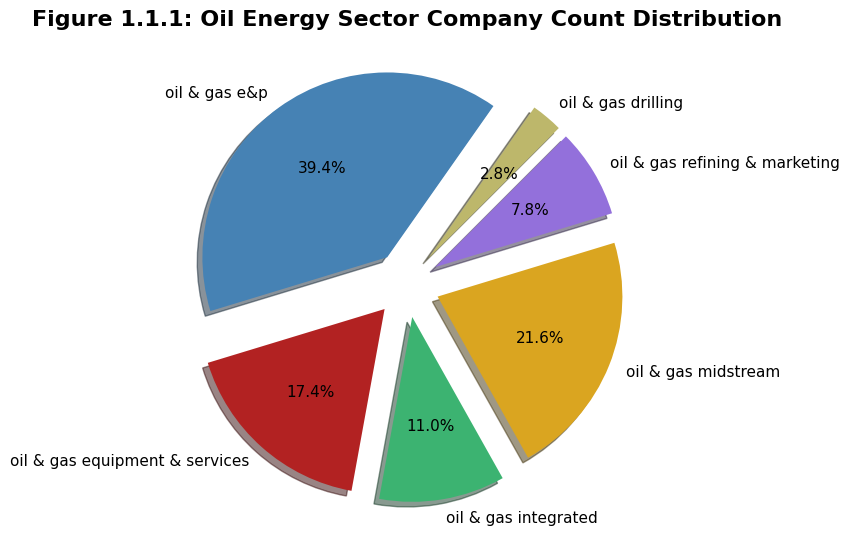

In [14]:
title = 'Figure 1.1.1: Oil Energy Sector Company Count Distribution'


matplotlibx.set_pie_chart_explode([0.03]*len(cmp_cnt_by_ind_series))

matplotlibx.set_pie_chart_colors(matplotlibx.pie_chart_colors[10:])

matplotlibx.set_pie_chart_title_fontsize(16.0)

matplotlibx.set_pie_textprops_fontsize(11.0)


matplotlibx.pie_chart(cmp_cnt_by_ind_series, title)

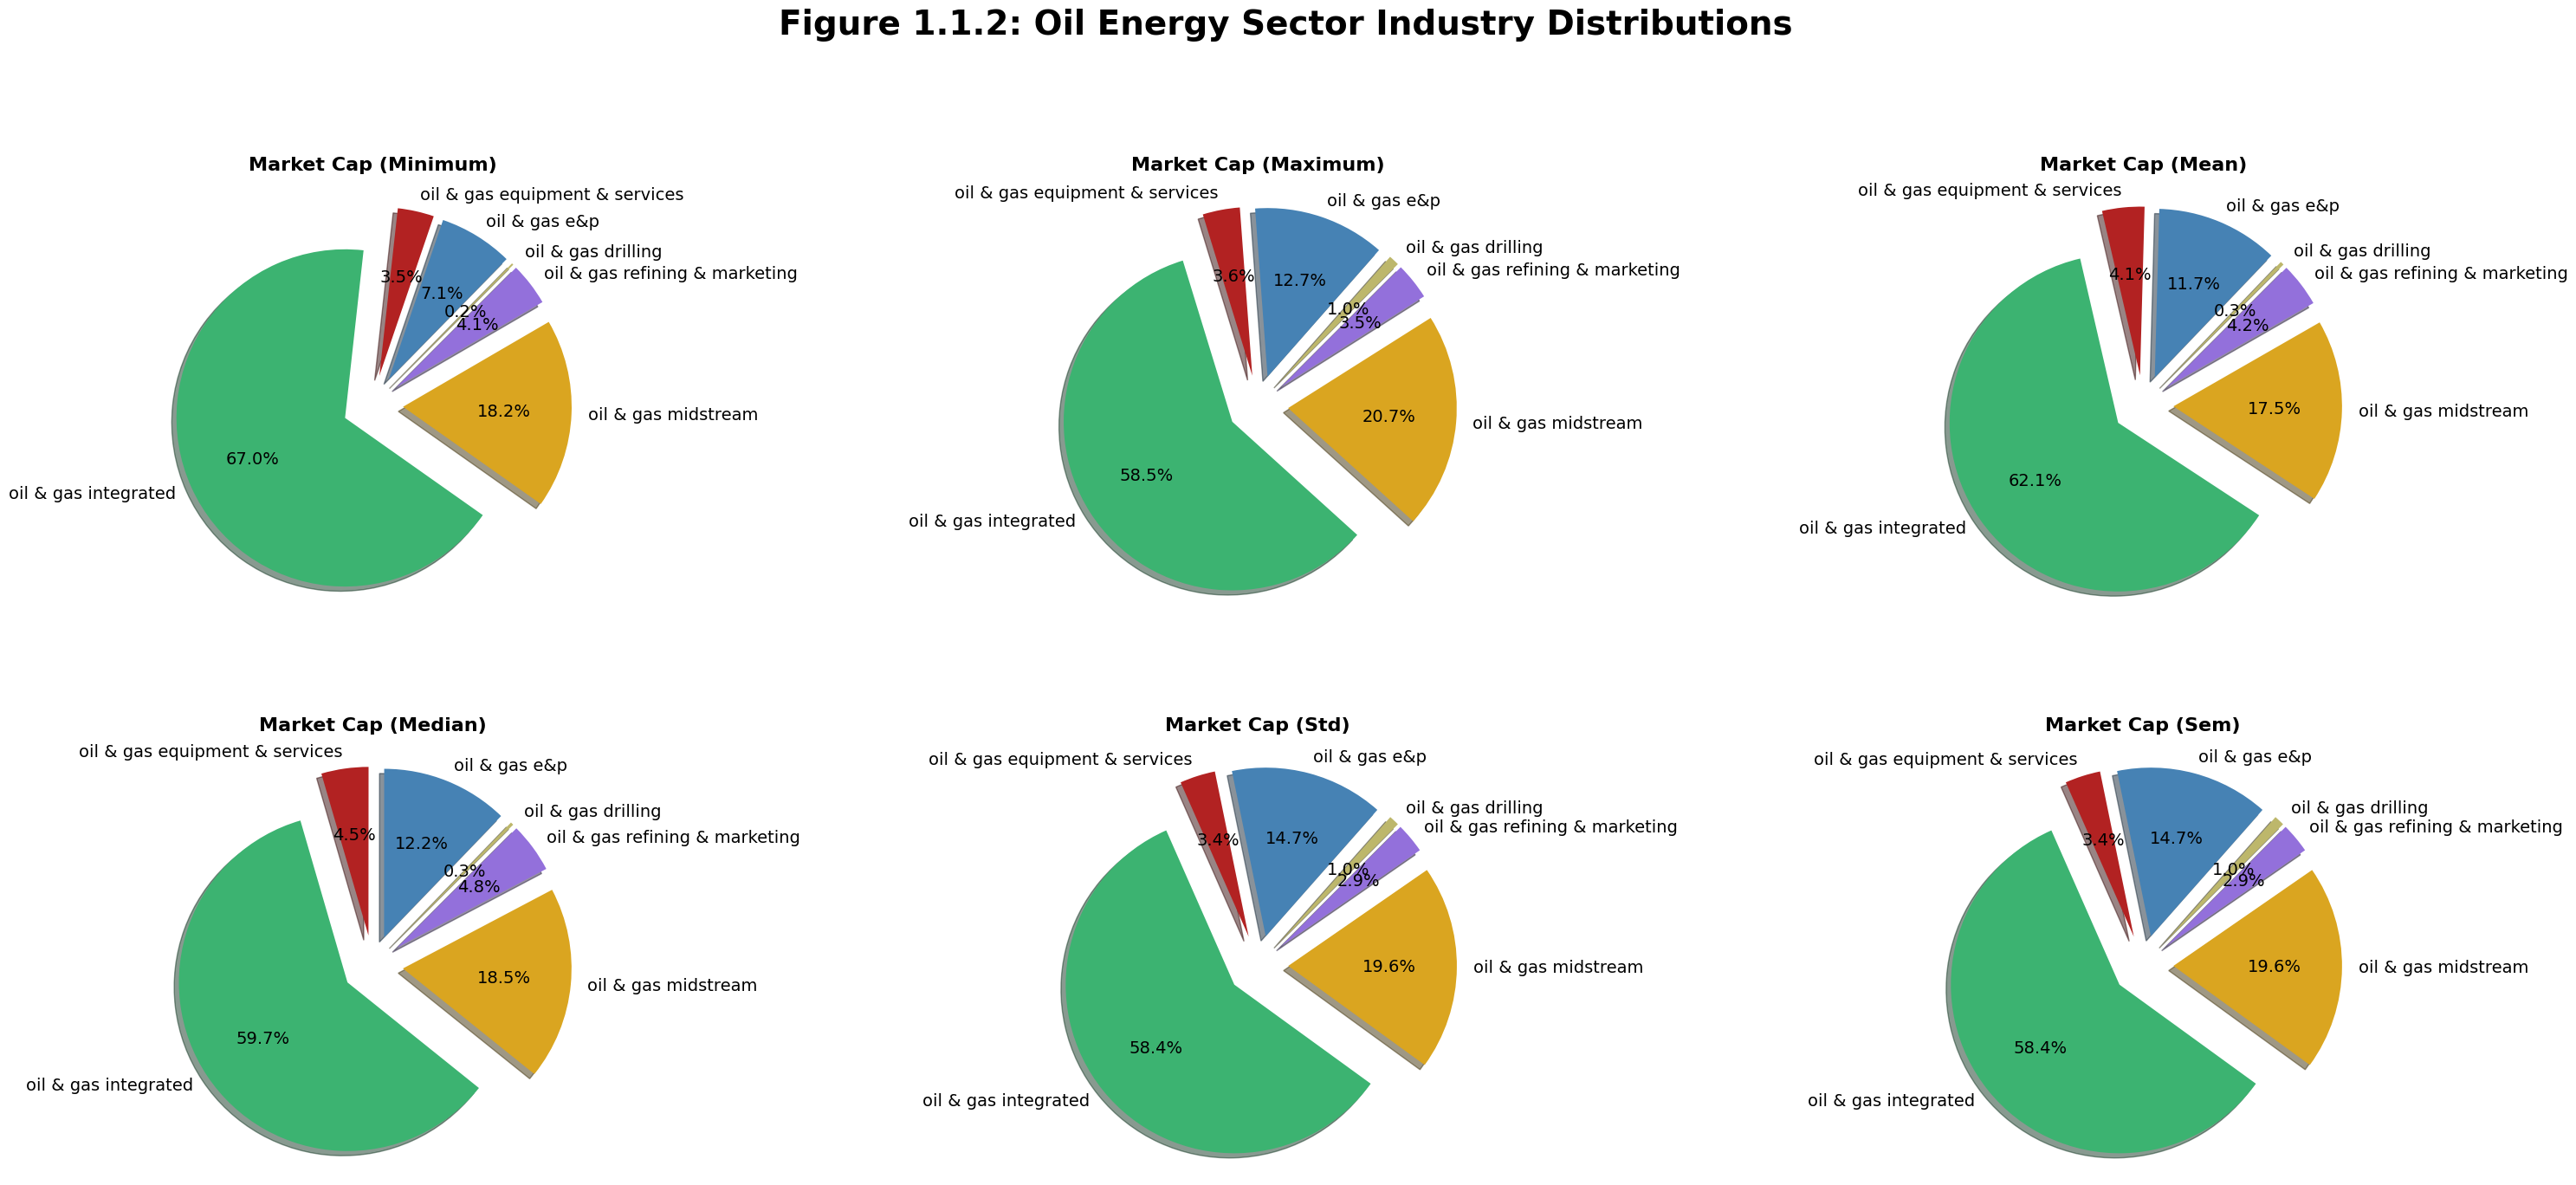

In [15]:
title = 'Figure 1.1.2: Oil Energy Sector Industry Distributions'


matplotlibx.set_pie_multichart_fig_dims(30.0, 15.0)

matplotlibx.set_pie_multichart_fig_spaces(1.1, 0.0)

matplotlibx.set_pie_textprops_fontsize(14.0)


matplotlibx.pie_multichart(oil_sctr_by_ind_df.iloc[:-1, 1:], title)

## **Section 1.2: Market Capitalization (Mean) Analysis**

### **Oil Industry Market Capitalization (Mean) Summary Statistics**

In [16]:
mean_cap_by_ind_stats_df = assetx.rtn_industry_stats_summary(oil_cmps_df, 'mean_market_cap')

logx.log_write_obj(mean_cap_by_ind_stats_df)

In [17]:
title = 'Table 1.2: Oil Industry Market Capitalization (Mean) Statistics'

fmt_dict \
    = {'lower_quartile': pandasx.fmt_dict['curr_flt_int'],
       'upper_quartile': pandasx.fmt_dict['curr_flt_int'],
       'iqr_range':      pandasx.fmt_dict['curr_flt_int'],
       'lower_boundary': pandasx.fmt_dict['curr_flt_int'],
       'upper_boundary': pandasx.fmt_dict['curr_flt_int'],
       'mean':           pandasx.fmt_dict['curr_flt_int'],
       'median':         pandasx.fmt_dict['curr_flt_int']}

pandasx.rtn_fmt_tbl(mean_cap_by_ind_stats_df, title).format(fmt_dict)

industry,lower_quartile,upper_quartile,iqr_range,lower_boundary,upper_boundary,mean,median,company_count,outliers_count
oil & gas drilling,"$1,637,580,666","$2,551,869,267","$914,288,601","$266,147,765","$3,009,013,567","$1,948,557,777","$1,854,526,057",6,1
oil & gas e&p,"$66,647,319","$2,627,339,879","$2,560,692,560","$-3,774,391,521","$3,907,686,159","$4,556,181,020","$518,578,497",86,16
oil & gas equipment & services,"$174,216,070","$1,675,231,579","$1,501,015,509","$-2,077,307,194","$2,425,739,334","$3,564,457,386","$663,425,092",38,7
oil & gas integrated,"$19,764,468,217","$121,502,227,650","$101,737,759,434","$-132,842,170,934","$172,371,107,367","$86,567,981,219","$71,576,141,701",24,4
oil & gas midstream,"$574,971,308","$20,926,352,255","$20,351,380,948","$-29,952,100,113","$31,102,042,729","$12,473,343,311","$1,653,354,295",47,7
oil & gas refining & marketing,"$1,344,047,095","$5,532,627,411","$4,188,580,315","$-4,938,823,377","$7,626,917,568","$8,270,231,545","$2,165,604,323",17,4


### **Display Oil Industry Market Capitalization (Mean) Summary Statistics**

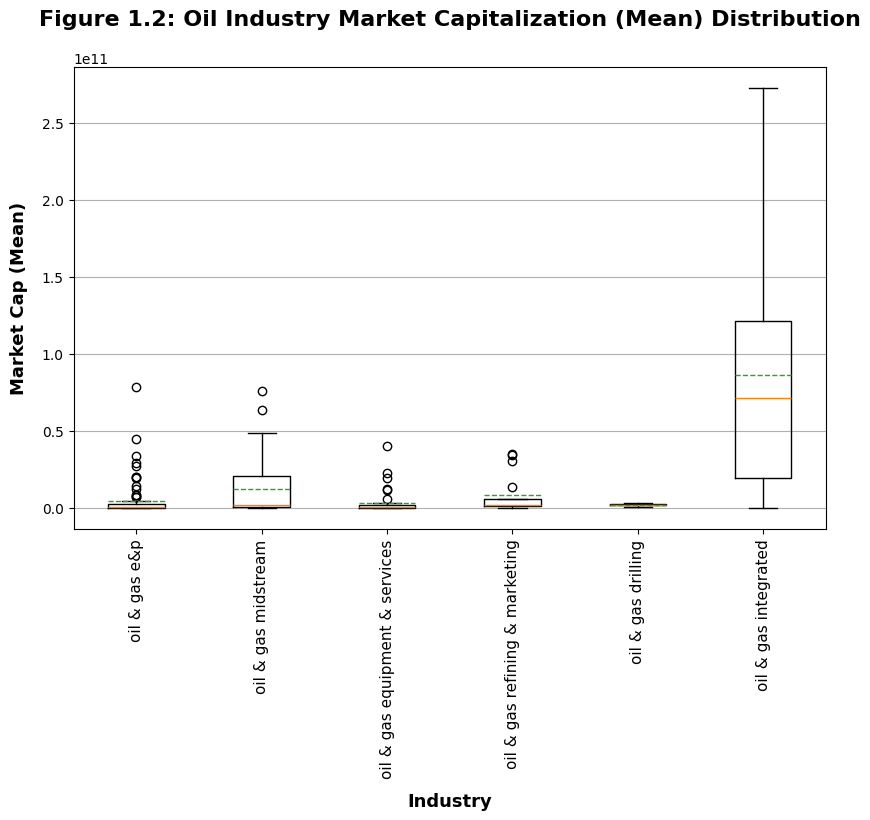

In [18]:
title = 'Figure 1.2: Oil Industry Market Capitalization (Mean) Distribution'


matplotlibx.set_boxplot_chart_xylabels('Industry', 'Market Cap (Mean)')

matplotlibx.set_boxplot_chart_xycols('industry', 'mean_market_cap')

matplotlibx.set_boxplot_chart_title_fontsize(16.0)

matplotlibx.set_boxplot_chart_title_pad(30.0)

matplotlibx.set_boxplot_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_boxplot_chart_xyticks_fontsize(11.0, 11.0)


matplotlibx.boxplot_chart(oil_cmps_df, title)

## **Section 1.3: Market Capitalization (Median) Analysis**

### **Oil Industry Market Capitalization (Median) Summary Statistics**

In [19]:
median_cap_by_ind_stats_df = assetx.rtn_industry_stats_summary(oil_cmps_df, 'median_market_cap')

logx.log_write_obj(median_cap_by_ind_stats_df)

In [20]:
title = 'Table 1.3: Oil Industry Market Capitalization (Median) Statistics'

fmt_dict \
    = {'lower_quartile': pandasx.fmt_dict['curr_flt_int'],
       'upper_quartile': pandasx.fmt_dict['curr_flt_int'],
       'iqr_range':      pandasx.fmt_dict['curr_flt_int'],
       'lower_boundary': pandasx.fmt_dict['curr_flt_int'],
       'upper_boundary': pandasx.fmt_dict['curr_flt_int'],
       'mean':           pandasx.fmt_dict['curr_flt_int'],
       'median':         pandasx.fmt_dict['curr_flt_int']}

pandasx.rtn_fmt_tbl(median_cap_by_ind_stats_df, title).format(fmt_dict)

industry,lower_quartile,upper_quartile,iqr_range,lower_boundary,upper_boundary,mean,median,company_count,outliers_count
oil & gas drilling,"$762,894,154","$2,004,167,113","$1,241,272,960","$-1,099,015,286","$2,624,803,593","$1,445,240,023","$1,141,312,678",6,1
oil & gas e&p,"$60,380,410","$2,544,367,472","$2,483,987,061","$-3,665,600,182","$3,786,361,003","$4,209,080,823","$449,692,673",86,14
oil & gas equipment & services,"$117,888,508","$1,663,843,061","$1,545,954,553","$-2,201,043,321","$2,436,820,337","$3,526,260,356","$622,163,076",38,7
oil & gas integrated,"$13,595,159,625","$95,852,020,465","$82,256,860,839","$-109,790,131,634","$136,980,450,884","$73,855,047,182","$54,684,859,263",24,4
oil & gas midstream,"$549,838,948","$18,543,381,857","$17,993,542,909","$-26,440,475,416","$27,540,153,311","$11,678,653,586","$1,253,868,920",47,8
oil & gas refining & marketing,"$1,397,921,768","$5,246,947,090","$3,849,025,322","$-4,375,616,215","$7,171,459,751","$8,333,766,948","$1,963,370,515",17,4


### **Display Oil Industry Market Capitalization (Median) Summary Statistics**

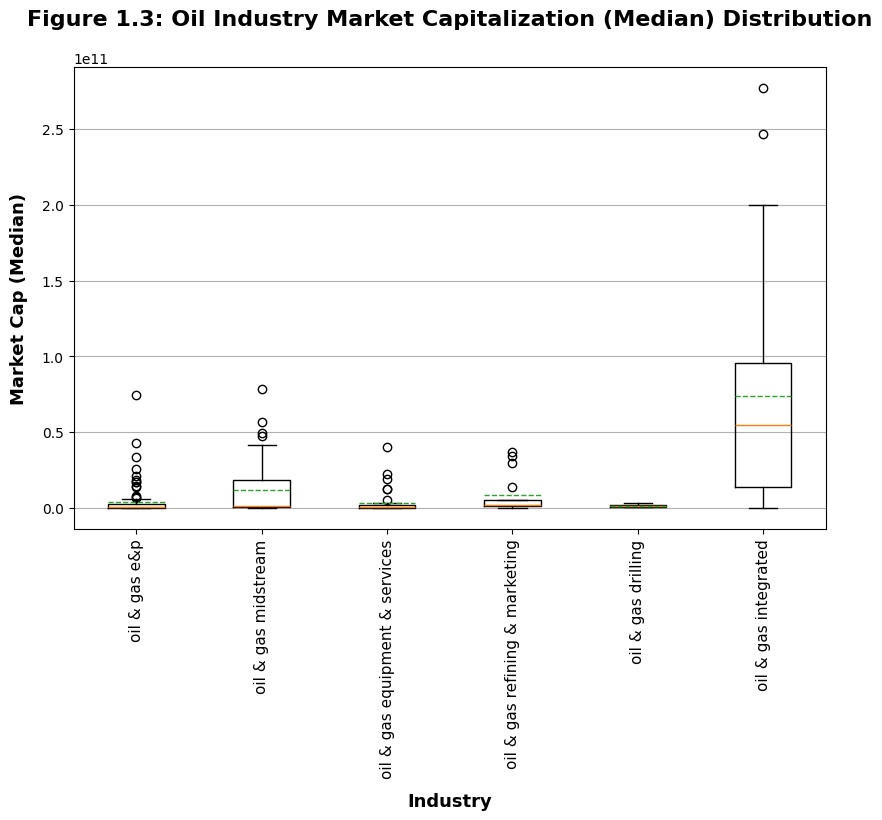

In [21]:
title = 'Figure 1.3: Oil Industry Market Capitalization (Median) Distribution'


matplotlibx.set_boxplot_chart_xylabels('Industry', 'Market Cap (Median)')

matplotlibx.set_boxplot_chart_xycols('industry', 'median_market_cap')

matplotlibx.set_boxplot_chart_title_fontsize(16.0)

matplotlibx.set_boxplot_chart_title_pad(30.0)

matplotlibx.set_boxplot_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_boxplot_chart_xyticks_fontsize(11.0, 11.0)


matplotlibx.boxplot_chart(oil_cmps_df, title)

# <br> **Part 2: OES Index Construction and Comparison**

## **Section 2.1: Oil & Gas Energy Sector (OES) Index from All Oil Companies**

### **Geographic Locations**

In [22]:
size_factor_int = 1.0*(10**9)

all_oil_cmps_geo_df = assetx.rtn_geo_df(oil_cmps_df, 'median_market_cap', size_factor_int)

logx.log_write_obj(all_oil_cmps_geo_df)

In [23]:
title = 'Figure 2.1.1: All Oil Companies World Map'


mapx.set_folium_name('company_name')

mapx.set_folium_marker_size('marker_size')

mapx.set_tooltip_cols(['symbol', 'company_name', 'industry', 'address', 'longitude', 'latitude'])


mapx.disp_folium_circles_df(all_oil_cmps_geo_df, title)

### **Calculate OES Index from the Market Capitalizations of All Oil Companies**

In [24]:
cmp_idx_wgts_all_series \
    = oil_cmps_df['median_market_cap'] / ttl_median_markt_cap_in_sector_flt

all_median_idx_series \
    = assetx.rtn_sctr_mrkt_idx_file \
        (oil_cmps_df['symbol'],
         cmp_idx_wgts_all_series,
         assetx.config_dict['file']['all_mdn'])

logx.log_write_obj(all_median_idx_series)

In [25]:
title    = 'Table 2.1: Oil Energy Sector Index (All)'

fmt_dict = {'prices': pandasx.fmt_dict['curr_flt']}

pandasx.rtn_fmt_tbl(all_median_idx_series.to_frame(), title, hide_idx_bool = False).format(fmt_dict)

,prices
2020-01-22,$63.98
2020-01-23,$62.37
2020-01-24,$60.25
2020-01-27,$59.15
2020-01-28,$59.32
2020-01-29,$59.94
2020-01-30,$59.08
2020-01-31,$57.55
2020-02-03,$57.33
2020-02-04,$58.03


### **Display Oil & Gas Energy Sector (OES) Index from All Oil Companies**

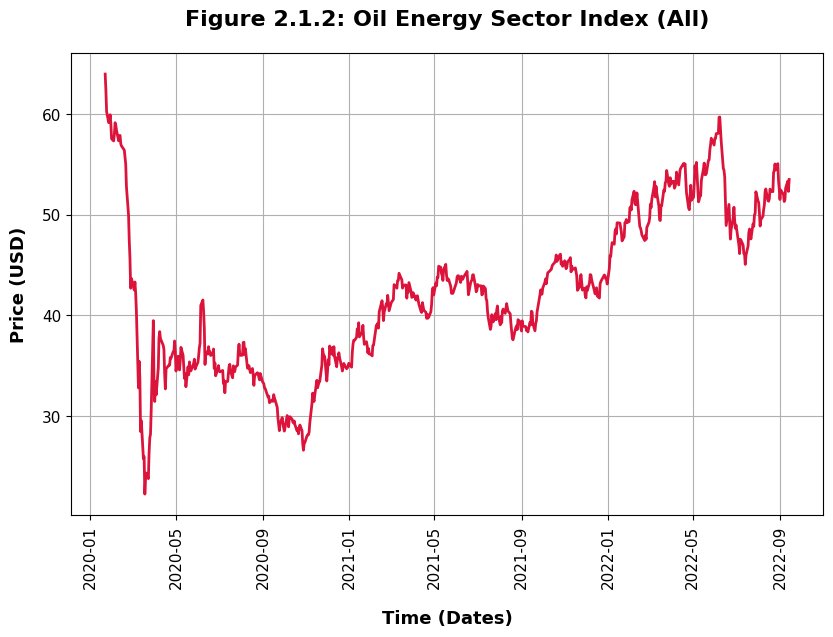

In [26]:
title = 'Figure 2.1.2: Oil Energy Sector Index (All)'


matplotlibx.set_line_chart_xylabels('Time (Dates)', 'Price (USD)')

matplotlibx.set_line_chart_colors(matplotlibx.stacked_line_chart_colors[7:])

matplotlibx.set_line_chart_xylabels_display(True, True)

matplotlibx.set_line_chart_legend_display(False)

matplotlibx.set_line_chart_title_fontsize(16.0)

matplotlibx.set_line_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_line_chart_xyticks_fontsize(11.0, 11.0)

matplotlibx.set_line_chart_xylabels_pad(15.0, 10.0)

matplotlibx.set_line_chart_marker_size(0.0)

matplotlibx.set_line_chart_linewidth(2.0)

matplotlibx.set_line_chart_xyticks_rotation(90.0, 0.0)


matplotlibx.line_chart(all_median_idx_series, title)

## **Section 2.2: Oil & Gas Energy Sector (OES) Index from All Oil Companies (%)**

### **Median Market Capitalization Index Calculation from All Oil Companies (%)**

In [27]:
all_median_idx_pct_series = dtypesx.cnv_to_pct_chg(all_median_idx_series)

all_median_idx_pct_series = all_median_idx_pct_series.rename('prices')

logx.log_write_obj(all_median_idx_pct_series)

In [28]:
title = 'Table 2.2: Oil Energy Sector Index (All) (%)'

fmt_dict = {'prices': pandasx.fmt_dict['pct_flt']}

pandasx.rtn_fmt_tbl \
    (all_median_idx_pct_series.to_frame(), 
     title, 
     hide_idx_bool = False) \
        .format(fmt_dict)

,prices
2020-01-23,-2.51%
2020-01-24,-3.41%
2020-01-27,-1.83%
2020-01-28,0.29%
2020-01-29,1.03%
2020-01-30,-1.42%
2020-01-31,-2.60%
2020-02-03,-0.37%
2020-02-04,1.23%
2020-02-05,1.92%


### **Display Oil & Gas Energy Sector (OES) Index from All Oil Companies (%)**

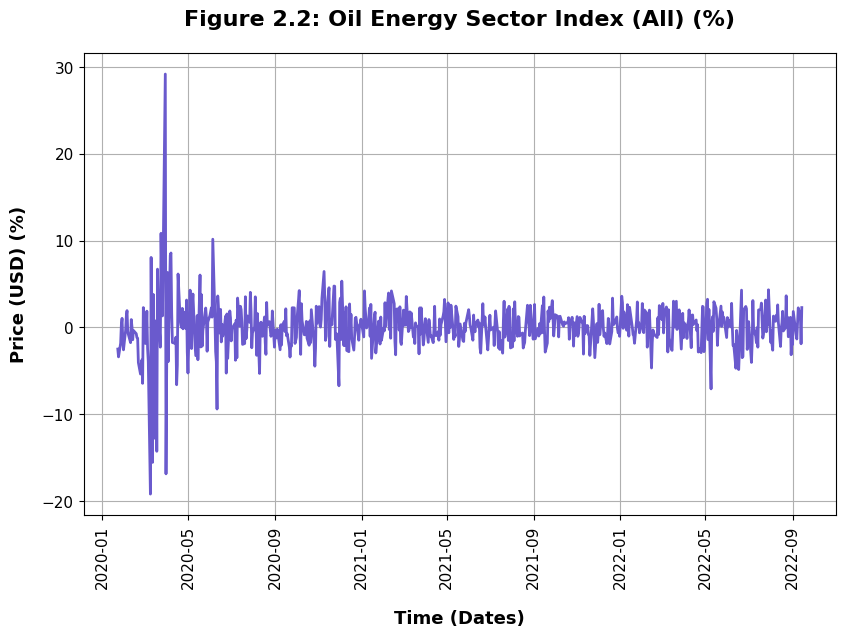

In [29]:
title = 'Figure 2.2: Oil Energy Sector Index (All) (%)'


matplotlibx.set_line_chart_xylabels('Time (Dates)', 'Price (USD) (%)')

matplotlibx.set_line_chart_colors(matplotlibx.stacked_line_chart_colors[8:])

matplotlibx.set_line_chart_title_fontsize(16.0)

matplotlibx.set_line_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_line_chart_xyticks_fontsize(11.0, 11.0)


matplotlibx.line_chart(all_median_idx_pct_series, title)

## **Section 2.3: Oil & Gas Energy Sector (OES) Index from Top Oil Company in Each Industry**

### **Top Oil Company in Each Industry from Market Capitalization (Median)**

In [30]:
max_median_cap_by_ind_series \
    = oil_cmps_df.groupby('industry')['median_market_cap'].max()

logx.log_write_obj(max_median_cap_by_ind_series)

In [31]:
top_oil_cmps_df \
    = oil_cmps_df \
        .apply(lambda x: x[oil_cmps_df['median_market_cap'] \
        .isin(max_median_cap_by_ind_series.to_numpy())])

top_oil_cmps_df = top_oil_cmps_df.reset_index(drop = True)

logx.log_write_obj(top_oil_cmps_df)

In [32]:
title = 'Table 2.3.1: Top Oil Company in Each Industry from Market Capitalization (Median)'

fmt_dict \
    = {'min_market_cap':    pandasx.fmt_dict['curr_flt_int'],
       'max_market_cap':    pandasx.fmt_dict['curr_flt_int'],
       'mean_market_cap':   pandasx.fmt_dict['curr_flt_int'],
       'median_market_cap': pandasx.fmt_dict['curr_flt_int'],
       'std_market_cap':    pandasx.fmt_dict['curr_flt_int'],
       'sem_market_cap':    pandasx.fmt_dict['curr_flt_int']}

pandasx.rtn_fmt_tbl(top_oil_cmps_df, title).format(fmt_dict)

symbol,company_name,industry,address,longitude,latitude,min_market_cap,max_market_cap,mean_market_cap,median_market_cap,std_market_cap,sem_market_cap
COP,conocophillips,oil & gas e&p,"925 north eldridge parkway, houston, tx 77079-2703, united states",-95.617771,29.783221,"$24,412,416,925","$160,064,149,137","$78,571,751,650","$74,445,925,570","$34,696,017,696","$1,342,429,228"
ENB,enbridge inc.,oil & gas midstream,"200, fifth avenue place, calgary, ab t2p 3l8, canada",-114.066108,51.045748,"$47,916,578,980","$96,313,842,921","$75,931,974,472","$78,381,415,002","$11,079,092,826","$428,662,971"
HP,"helmerich & payne, inc.",oil & gas drilling,"222 north detroit avenue, tulsa, ok 74120, united states",-95.990400,36.159788,"$1,411,430,400","$5,818,388,080","$3,157,893,408","$3,008,912,095","$1,055,584,173","$40,841,778"
MPC,marathon petroleum corporation,oil & gas refining & marketing,"539 south main street, findlay, oh 45840-3229, united states",-83.650163,41.036497,"$10,807,337,687","$61,484,082,659","$34,940,402,198","$37,218,113,773","$10,544,632,544","$407,984,082"
SHEL,shell plc,oil & gas integrated,"shell centre, london, se1 7na, united kingdom",-0.116779,51.503840,"$165,393,650,330","$439,417,727,795","$272,772,964,860","$276,969,339,046","$60,455,987,531","$2,339,112,385"
SLB,slb n.v.,oil & gas equipment & services,"5599 san felipe, houston, tx 77056, united states",-95.474340,29.749961,"$15,735,732,922","$70,091,980,000","$40,208,608,990","$40,372,672,714","$12,538,642,065","$485,134,627"


### **Geographic Locations**

In [33]:
size_factor_int     = 1.0*(10**9)

top_oil_cmps_geo_df = assetx.rtn_geo_df(top_oil_cmps_df, 'median_market_cap', size_factor_int)

logx.log_write_obj(top_oil_cmps_geo_df)

In [34]:
title = 'Figure 2.3.1: Top Oil Companies World Map'

mapx.disp_folium_circles_df(top_oil_cmps_geo_df, title)

### **Calculate OES Index from the Market Capitalizations of Top Oil Company in Each Industry**

In [35]:
ttl_top_cmps_median_cap_flt = top_oil_cmps_df['median_market_cap'].sum()

cmp_idx_wghts_top_series \
    = top_oil_cmps_df['median_market_cap'] / ttl_top_cmps_median_cap_flt


top_median_idx_series \
    = assetx.rtn_sctr_mrkt_idx_file \
        (top_oil_cmps_df['symbol'],
         cmp_idx_wghts_top_series,
         assetx.config_dict['file']['top_mdn'])

logx.log_write_obj(top_median_idx_series)

In [36]:
title    = 'Table 2.3.2: Oil Energy Sector Index (Top)'

fmt_dict = {'prices': pandasx.fmt_dict['curr_flt']}

pandasx.rtn_fmt_tbl(top_median_idx_series.to_frame(), title, hide_idx_bool = False).format(fmt_dict)

,prices
2020-01-22,$53.87
2020-01-23,$53.82
2020-01-24,$53.51
2020-01-27,$52.38
2020-01-28,$52.36
2020-01-29,$52.19
2020-01-30,$51.33
2020-01-31,$50.08
2020-02-03,$49.43
2020-02-04,$49.43


### **Display Oil & Gas Energy Sector (OES) Index from Top Oil Companies**

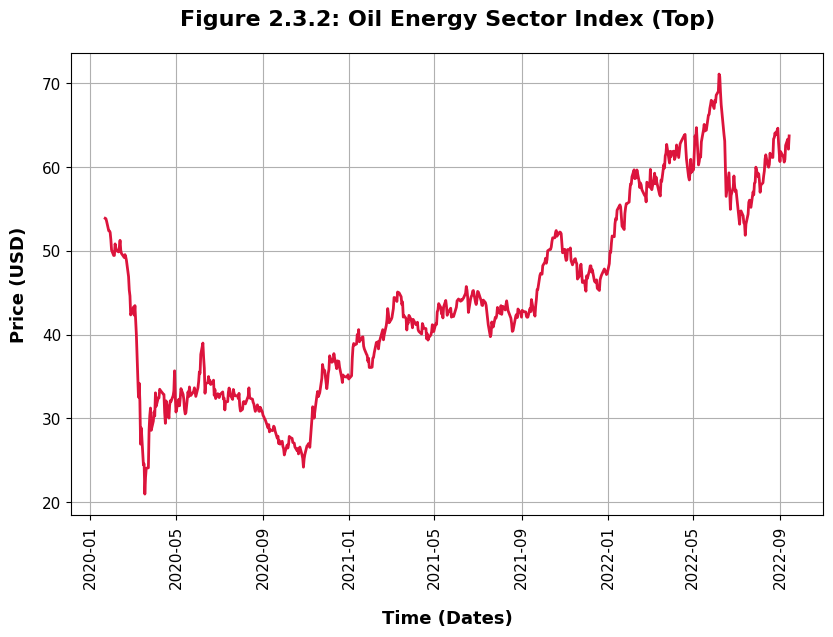

In [37]:
title = 'Figure 2.3.2: Oil Energy Sector Index (Top)'


matplotlibx.set_line_chart_xylabels('Time (Dates)', 'Price (USD)')

matplotlibx.set_line_chart_colors(matplotlibx.stacked_line_chart_colors[7:])

matplotlibx.set_line_chart_title_fontsize(16.0)

matplotlibx.set_line_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_line_chart_xyticks_fontsize(11.0, 11.0)


matplotlibx.line_chart(top_median_idx_series, title)

## **Section 2.4: Oil & Gas Energy Sector (OES) Index from Top Oil Company in Each Industry (%)**

### **Median Market Capitalization Index Calculation from Top Companies (%)**

In [38]:
top_median_idx_pct_series = dtypesx.cnv_to_pct_chg(top_median_idx_series)

top_median_idx_pct_series = top_median_idx_pct_series.rename('prices')

logx.log_write_obj(top_median_idx_pct_series)

In [39]:
title    = 'Table 2.4: Oil Energy Sector Index (Top) (%)'

fmt_dict = {'prices': pandasx.fmt_dict['pct_flt']}

pandasx.rtn_fmt_tbl(top_median_idx_pct_series.to_frame(), title, hide_idx_bool = False).format(fmt_dict)

,prices
2020-01-23,-0.09%
2020-01-24,-0.57%
2020-01-27,-2.12%
2020-01-28,-0.03%
2020-01-29,-0.33%
2020-01-30,-1.65%
2020-01-31,-2.44%
2020-02-03,-1.30%
2020-02-04,0.01%
2020-02-05,2.79%


### **Display Oil & Gas Energy Sector (OES) Index from Top Oil Companies (%)**

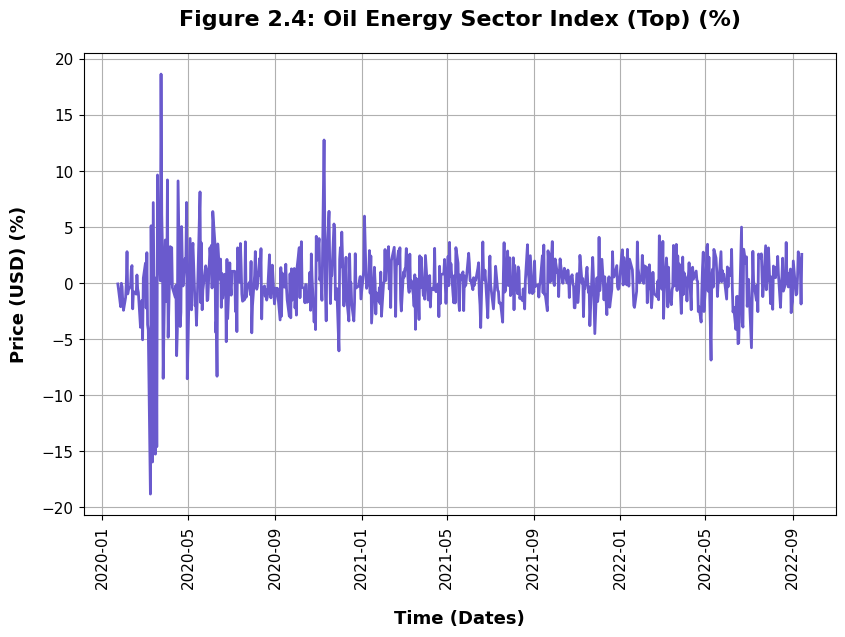

In [40]:
title = 'Figure 2.4: Oil Energy Sector Index (Top) (%)'


matplotlibx.set_line_chart_xylabels('Time (Dates)', 'Price (USD) (%)')

matplotlibx.set_line_chart_colors(matplotlibx.stacked_line_chart_colors[8:])

matplotlibx.set_line_chart_title_fontsize(16.0)

matplotlibx.set_line_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_line_chart_xyticks_fontsize(11.0, 11.0)


matplotlibx.line_chart(top_median_idx_pct_series, title)

## **Section 2.5: Oil & Gas Energy Sector (OES) Indices Comparison**

### **Create DataFrame OES (Top) Index vs. OES (All) Index**

In [41]:
oil_sctr_idxs_df \
    = pd.DataFrame \
        ({'oes_top_index': top_median_idx_series,
          'oes_all_index': all_median_idx_series})

logx.log_write_obj(oil_sctr_idxs_df)

In [42]:
title = 'Table 2.5.1: OES (Top) Index vs. OES (All) Index'

fmt_dict \
    = {'oes_top_index': pandasx.fmt_dict['curr_flt'],
       'oes_all_index': pandasx.fmt_dict['curr_flt']}

pandasx.rtn_fmt_tbl(oil_sctr_idxs_df, title, hide_idx_bool = False).format(fmt_dict)

,oes_top_index,oes_all_index
2020-01-22,$53.87,$63.98
2020-01-23,$53.82,$62.37
2020-01-24,$53.51,$60.25
2020-01-27,$52.38,$59.15
2020-01-28,$52.36,$59.32
2020-01-29,$52.19,$59.94
2020-01-30,$51.33,$59.08
2020-01-31,$50.08,$57.55
2020-02-03,$49.43,$57.33
2020-02-04,$49.43,$58.03


### **Display OES (Top) Index vs. OES (All) Index (Pre-Transformations)**

<Figure size 970.8x600 with 0 Axes>

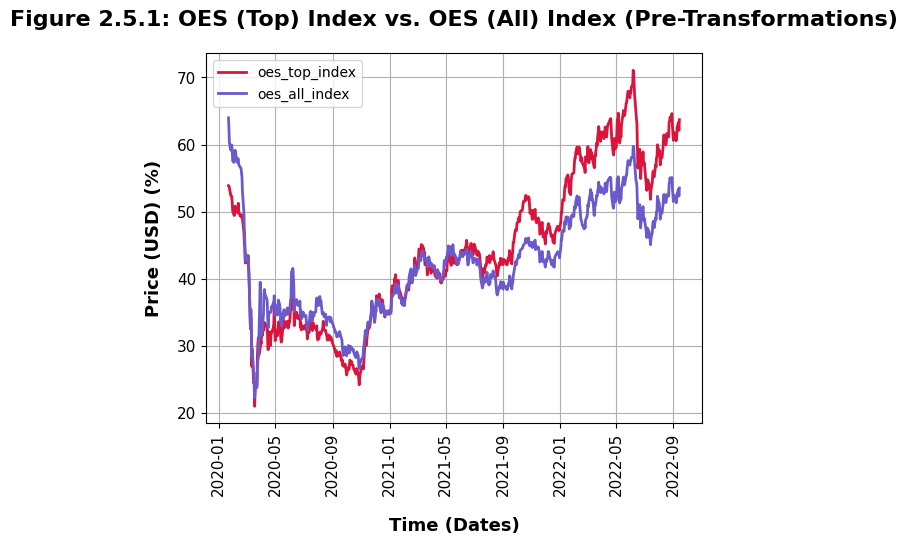

In [43]:
title = 'Figure 2.5.1: OES (Top) Index vs. OES (All) Index (Pre-Transformations)'


matplotlibx.set_line_chart_colors(matplotlibx.stacked_line_chart_colors[7:])

matplotlibx.set_line_chart_title_fontsize(16.0)

matplotlibx.set_line_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_line_chart_xyticks_fontsize(11.0, 11.0)


matplotlibx.line_chart(oil_sctr_idxs_df, title)

### **Transformations for Stationarity - OES (Top) Index vs. OES (All) Index**

In [44]:
trns_df                = mathx.crct_stnry_df(oil_sctr_idxs_df.to_dict(orient = 'series'))

top_median_idx2_series = trns_df['oes_top_index']

all_median_idx2_series = trns_df['oes_all_index']

TREND-STATIONARY TIME SERIES DETECTED: oes_top_index.

Detrending (optimal polynomial degree) time series oes_top_index...



TREND-STATIONARY TIME SERIES DETECTED: oes_all_index.

Detrending (optimal polynomial degree) time series oes_all_index...





### **Display OES (Top) Index vs. OES (All) Index (Post-Transformations)**

<Figure size 970.8x600 with 0 Axes>

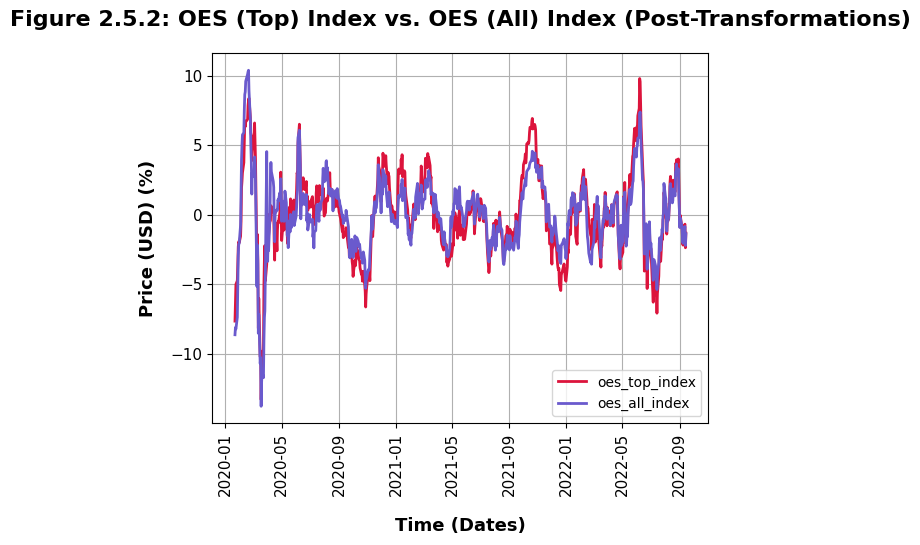

In [45]:
title = 'Figure 2.5.2: OES (Top) Index vs. OES (All) Index (Post-Transformations)'


matplotlibx.set_line_chart_colors(matplotlibx.stacked_line_chart_colors[7:])

matplotlibx.set_line_chart_title_fontsize(16.0)

matplotlibx.set_line_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_line_chart_xyticks_fontsize(11.0, 11.0)


matplotlibx.line_chart(trns_df, title)

### **AIC, Cross-validated R², and Overfitting Score for Polynomial Degree: OES (Top) Index vs. OES (All) Index**

In [46]:
title = 'Table 2.5.2: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree ' \
            + '- OES (All) Index vs. OES (Top) Index'

best_deg, scores_dict, _, results_df \
    = mathx.best_poly_degree \
        (all_median_idx2_series, 
         top_median_idx2_series)

corr_method \
    = mathx.find_opt_corr_method \
        (all_median_idx2_series, 
         top_median_idx2_series)

pandasx.rtn_fmt_tbl(results_df, title) \
    .map(pandasx.highlight_bool_col, subset = ['overfit']) \
    .apply(pandasx.highlight_val_row, col = 'degree', val = best_deg, axis = 1)

degree,train_r2,cv_r2,cv_r2_std,cv_norm,aic,aic_norm,overfit,combined_score
1,0.82,0.76,0.10,1.00,327.45,0.00,False,0.50
2,0.82,0.76,0.10,1.00,327.28,0.00,False,0.50
3,0.83,0.74,0.16,1.00,291.02,0.52,False,0.76
4,0.84,-0.16,1.96,1.00,261.14,0.95,False,0.98
5,0.84,-1.65,4.92,1.00,259.44,0.98,False,0.99
6,0.84,-26.76,55.15,1.00,260.83,0.96,True,0.98
7,0.84,-318.31,638.22,1.00,260.84,0.96,True,0.98
8,0.84,"-2,203.27","4,408.14",0.99,257.94,1.00,True,1.00
9,0.84,"-286,826.40","573,654.40",0.00,259.59,0.98,True,0.49
10,0.85,"-32,973.93","65,949.45",0.89,258.17,1.00,True,0.94


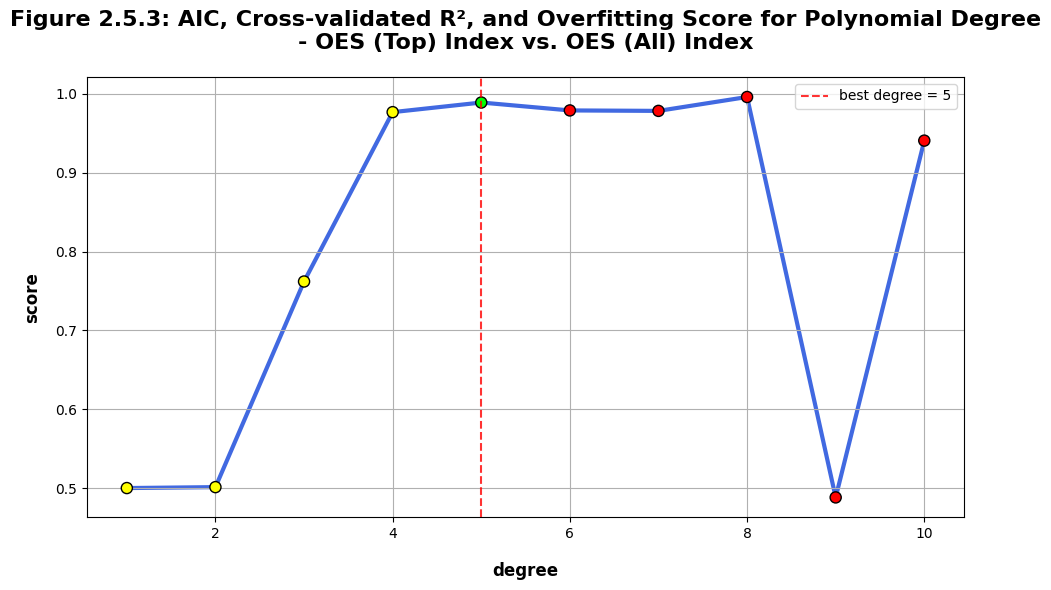

In [47]:
title = 'Figure 2.5.3: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree\n' \
            + '- OES (Top) Index vs. OES (All) Index'


matplotlibx.set_corr_scores_xylabels('degree', 'score')

matplotlibx.set_corr_scores_marker_size(8.0)

matplotlibx.set_lag_corr_method(corr_method)


matplotlibx.plot_corr_scores(scores_dict, title, best_deg)

### **Correlation (Spearman): OES (Top) Index vs. OES (All) Index**

In [48]:
title = f'Table 2.5.3: Correlation ({corr_method.title()}): OES (Top) Index vs. OES (All) Index'

pandasx.rtn_fmt_tbl(trns_df.corr(method = corr_method), title, hide_idx_bool = False)

,oes_top_index,oes_all_index
oes_top_index,1.00,0.90
oes_all_index,0.90,1.00


### **Scatter Plot: OES (Top) Index vs. OES (All) Index**

r-value (pearson):	0.907
r-value (spearman):	0.901
tau (kendall):		0.738

p-value (pearson):	0.000
p-value (spearman):	0.000
p-value (kendall):	0.000




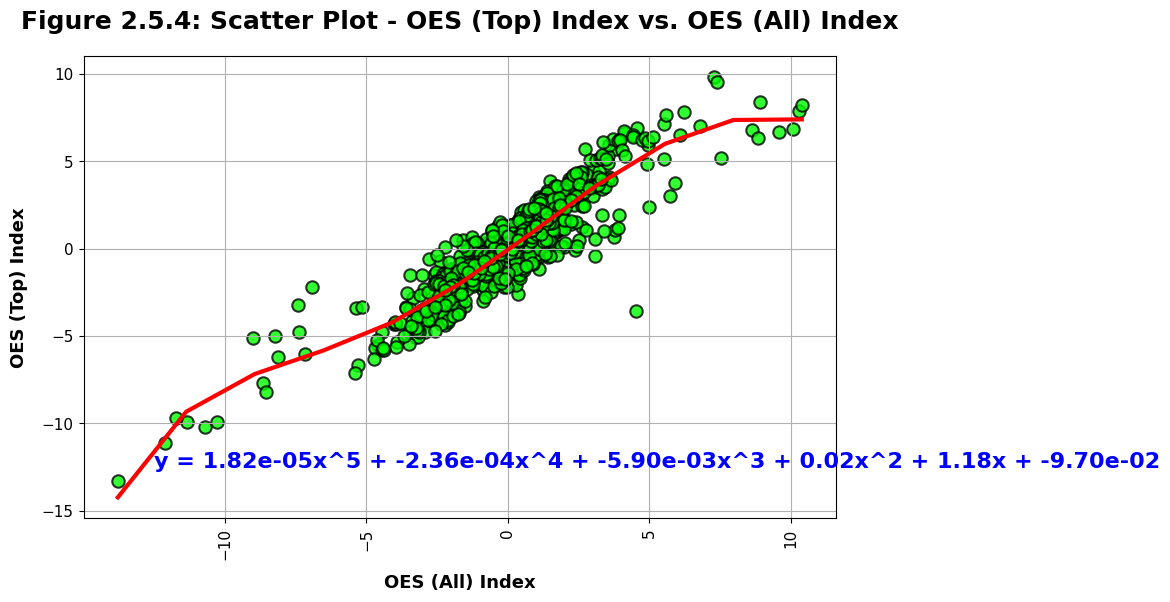

In [49]:
title = 'Figure 2.5.4: Scatter Plot - OES (Top) Index vs. OES (All) Index'


matplotlibx.set_scatterplot_chart_xylabels('OES (All) Index', 'OES (Top) Index')

matplotlibx.set_scatterplot_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_scatterplot_chart_xyticks_fontsize(11.0, 11.0)

matplotlibx.set_scatterplot_chart_title_fontsize(18.0)

matplotlibx.set_regr_eqn_coords(-12.5, -12.5)

matplotlibx.set_regr_degree(best_deg)


matplotlibx.scatterplot_chart([all_median_idx2_series, top_median_idx2_series], title)

### **The Granger Causality Test: OES (Top) Index -> OES (All) Index**

In [50]:
title           = 'Table 2.5.4: The Granger Causality Test - OES (Top) Index -> OES (All) Index'


grngr_mth, _, _ \
    = mathx.find_optimal_granger_method \
        (top_median_idx2_series, 
         all_median_idx2_series)

g_lag, _ \
    = mathx.find_optimal_granger_lag \
        (top_median_idx2_series, 
         all_median_idx2_series, 
         method = grngr_mth)


test_df, best_dict \
    = mathx.granger_causality_test \
        (top_median_idx2_series, 
         all_median_idx2_series, 
         max_lag = g_lag, 
         method  = grngr_mth)


pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
    .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
    .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
    .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,4.403785,0.036236,True,True,True,True,high confidence


### **The Granger Causality Test: OES (All) Index -> OES (Top) Index**

In [51]:
title = 'Table 2.5.5: The Granger Causality Test - OES (All) Index -> OES (Top) Index'

test_df, best_dict \
    = mathx.granger_causality_test \
        (all_median_idx2_series, 
         top_median_idx2_series, 
         max_lag = g_lag, 
         method  = grngr_mth)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,0.155542,0.693421,False,False,False,False,high confidence
2,1.650205,0.192801,False,False,False,False,high confidence
3,1.551045,0.200114,False,False,False,False,high confidence
4,2.732656,0.028220,True,True,True,True,high confidence


### **VAR/VECM Analysis: OES (Top) Index -> OES (All) Index**

In [52]:
title            = 'VAR/VECM Analysis: top_median_idx_series, all_median_idx_series'


results_dict     = mathx.fit_var_or_vecm(top_median_idx2_series, all_median_idx2_series)

x_y1_analysis_df = results_dict['summary_df']

msg              = results_dict['conclusion']


logx.print_and_log_text('\033[1m' + msg + '\033[0m')

logx.write_to_folder(msg, title)

OES_TOP_INDEX VS. OES_ALL_INDEX ANALYSIS

Model selected: VAR.

Series 'x' is stationary (ADF = -6.055461, p = 0.000000).

Series 'y' is stationary (ADF = -7.208123, p = 0.000000).

Trace and max-eigenvalue tests agree. Both series appear stationary at levels — VAR on levels is appropriate.

Recommended lag (BIC): 1.
AIC = 16, BIC = 1, HQIC = 1, FPE = 16.

VAR(1) fitted.
AIC = -0.818109, BIC = -0.777605.
Stability: UNSTABLE — roots outside unit circle; interpret with caution.

IRF (VAR, 30 periods):
A one-SD shock to x produces a positive net response in y.
Peak x→y effect at lag 9 (magnitude: 0.235499).
Cumulative x→y response: 4.993053.

FEVD (VAR, horizon = 20):
x shocks explain 78.20185% of y's forecast variance (substantial influence).
y's own shocks explain 21.79815% of its own variance.



### **Impulse Response Functions (IRF): OES (Top) Index vs. OES (All) Index**

In [53]:
title = 'Table 2.5.6: Impulse Response Functions (IRF) ' \
            + f'- OES (Top) Index vs. OES (All) Index'

try:

    test_df = results_dict['irf_result']['irf_df']

    irf_bool = True

    if len(test_df) > 0:

        display \
            (pandasx.rtn_fmt_tbl \
                (test_df, 
                 title, 
                 hide_idx_bool = False, 
                 line_cnt_int = len(test_df)) \
                    .highlight_min(color = 'mistyrose') \
                    .highlight_max(color = 'greenyellow') \
                    .apply(pandasx.highlight_median_col) \
                    .format('{:,.6f}'))

    else:

        irf_bool = False

        logx.write_to_folder \
            ('\nThere is no Impulse Response Function present with VECM model: ' \
                 + 'OES (Top) Index vs. OES (All) Index\n')
    
except:

    irf_bool = False

    logx.write_to_folder \
        ('\nThere is no Impulse Response Function present with VECM model: ' \
             + 'OES (Top) Index vs. OES (All) Index\n')

,x_shock_x_response,x_shock_y_response,y_shock_x_response,y_shock_y_response
period,,,,
0,1.000000,0.000000,0.000000,1.000000
1,0.921730,0.067399,0.013812,0.849320
2,0.850516,0.119368,0.024462,0.722275
3,0.785595,0.158706,0.032523,0.615092
4,0.726298,0.187741,0.038473,0.524602
5,0.672044,0.208404,0.042708,0.448148
6,0.622321,0.222297,0.045555,0.383499
7,0.576682,0.230745,0.047286,0.328784
8,0.534732,0.234845,0.048126,0.282430


### **Forecast Error Variance Decomposition (FEVD): OES (Top) Index vs. OES (All) Index**

In [54]:
if irf_bool:
    
    title = 'Table 2.5.7: Forecast Error Variance Decomposition (FEVD) ' \
            + '- OES (Top) Index vs. OES (All) Index'

else:

    title = 'Table 2.5.6: Forecast Error Variance Decomposition (FEVD) ' \
            + '- OES (Top) Index vs. OES (All) Index'    

test_df = results_dict['fevd_result']['fevd_df']

pandasx.rtn_fmt_tbl \
    (test_df, 
     title, 
     hide_idx_bool = False, 
     line_cnt_int = len(test_df)) \
        .highlight_min(color = 'mistyrose') \
        .highlight_max(color = 'greenyellow') \
        .apply(pandasx.highlight_median_col) \
        .format('{:,.6f}')

,y_variance_from_x,y_variance_from_y,x_variance_from_x,x_variance_from_y
period,,,,
0,0.644969,0.355031,1.000000,0.000000
1,0.663729,0.336271,0.999963,0.000037
2,0.680315,0.319685,0.999892,0.000108
3,0.694904,0.305096,0.999799,0.000201
4,0.707684,0.292316,0.999691,0.000309
5,0.718840,0.281160,0.999577,0.000423
6,0.728556,0.271444,0.999460,0.000540
7,0.736999,0.263001,0.999345,0.000655
8,0.744326,0.255674,0.999233,0.000767


### **Rolling R, Stability, and CV Score for Rolling Window: OES (Top) Index vs. OES (All) Index**

In [55]:
best_w, _, results_df \
    = mathx.find_optimal_rolling_window \
        (top_median_idx2_series, 
         all_median_idx2_series, 
         method = corr_method)

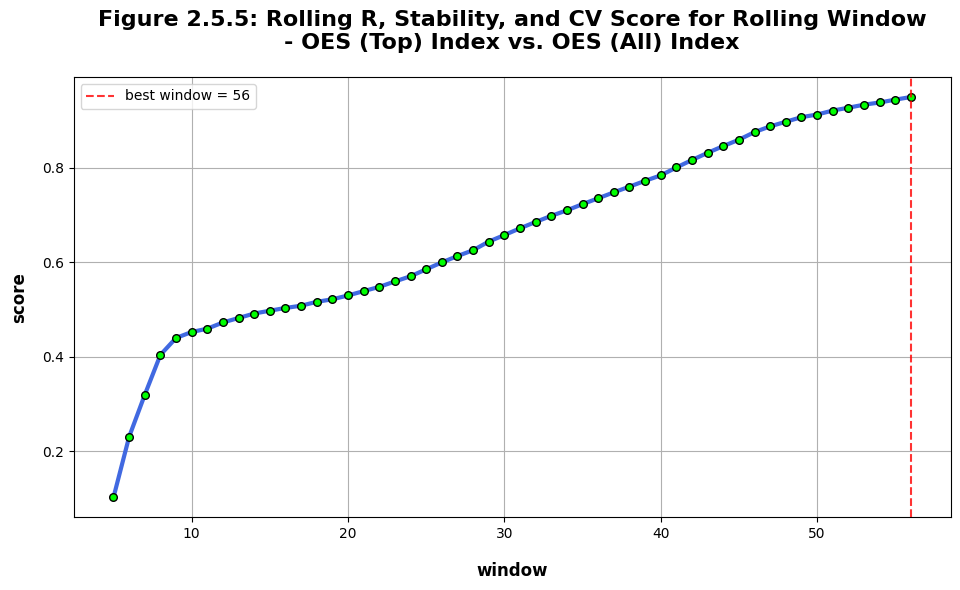

In [56]:
title = 'Figure 2.5.5: Rolling R, Stability, and CV Score for Rolling Window\n' \
            + '- OES (Top) Index vs. OES (All) Index'


matplotlibx.set_corr_scores_xylabels('window', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling R, Stability, and CV Score for Minimum Period: OES (Top) Index vs. OES (All) Index**

In [57]:
best_mp, _, results_df \
    = mathx.find_optimal_min_periods \
        (top_median_idx2_series, 
         all_median_idx2_series, 
         window = best_w, 
         method = corr_method)

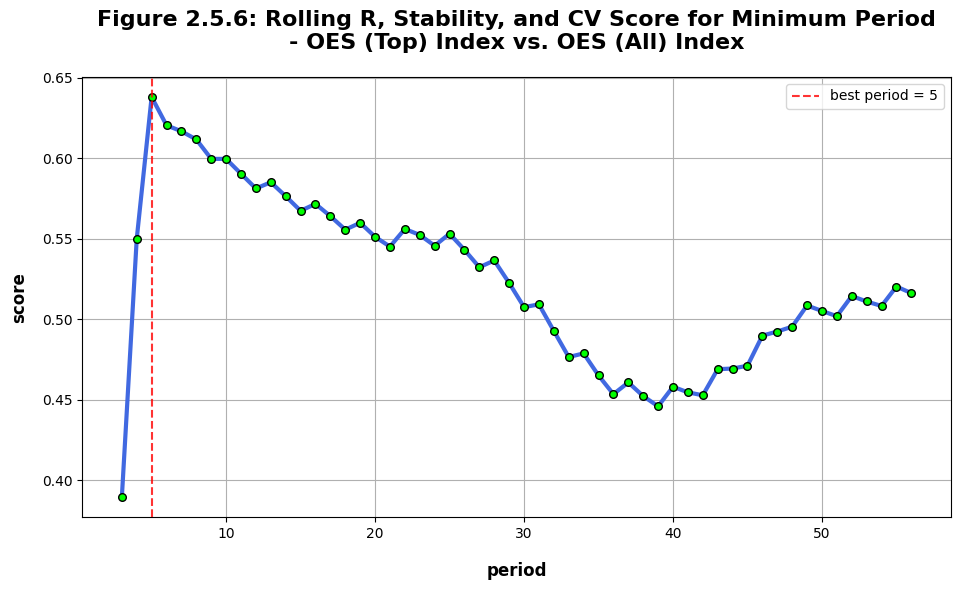

In [58]:
title = 'Figure 2.5.6: Rolling R, Stability, and CV Score for Minimum Period\n' \
            + '- OES (Top) Index vs. OES (All) Index'


matplotlibx.set_corr_scores_xylabels('period', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling Correlation: OES (Top) Index vs. OES (All) Index**

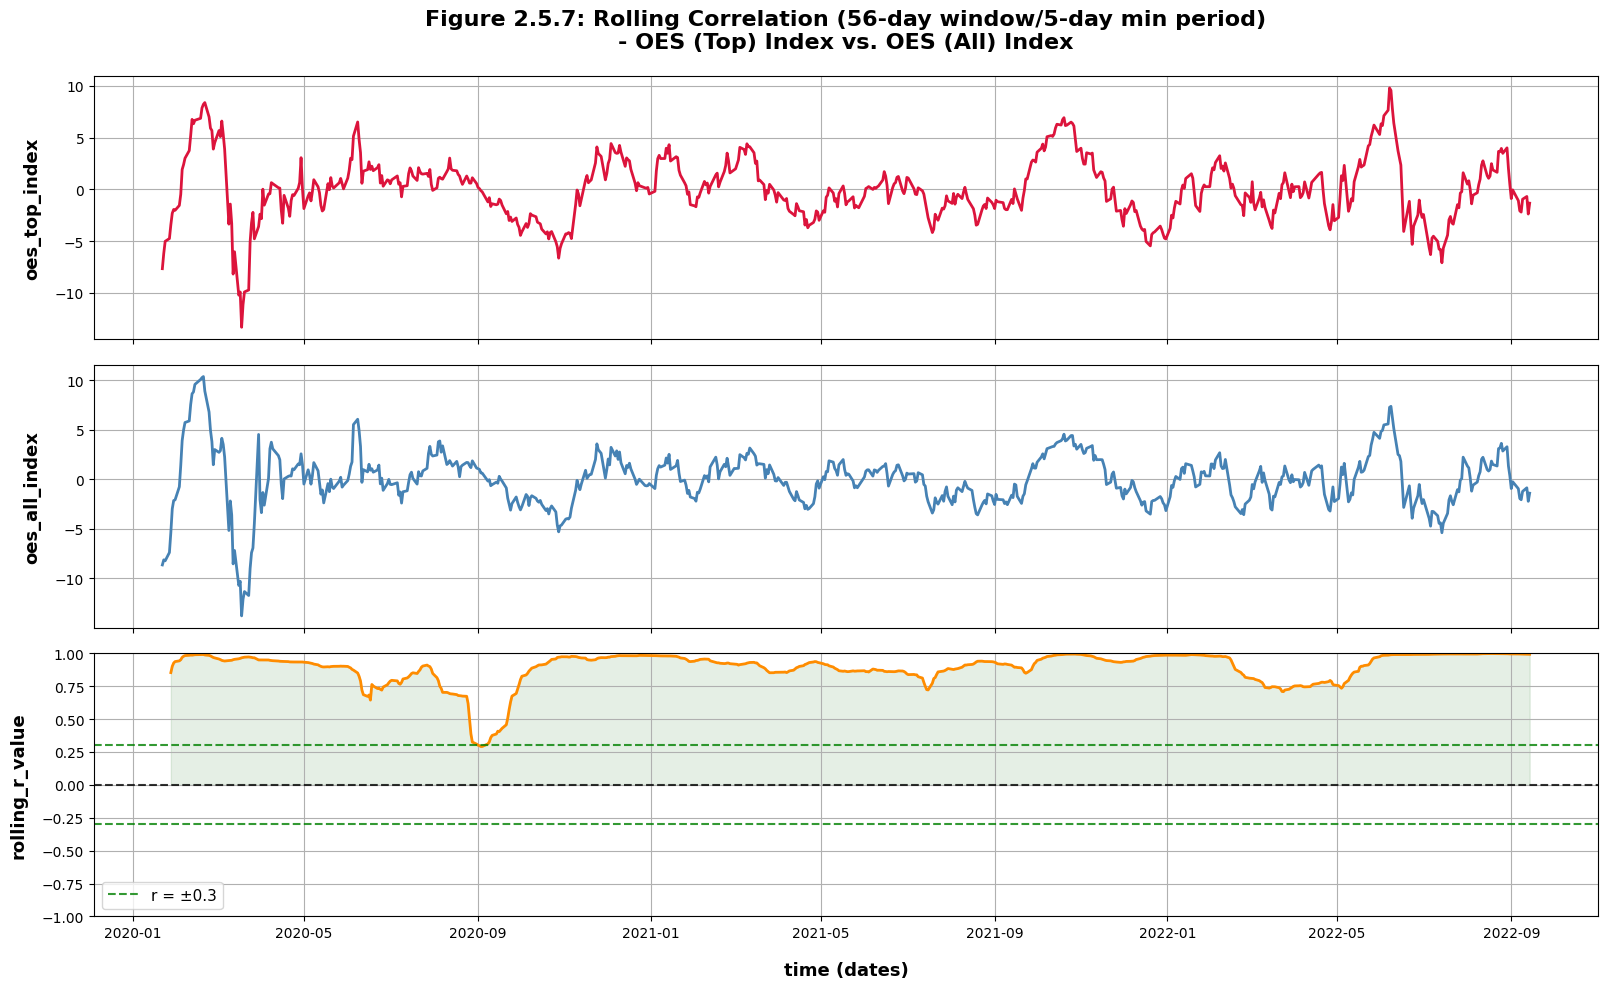

In [59]:
title \
    = f'Figure 2.5.7: Rolling Correlation ({best_w}-day window/{best_mp}' \
        + '-day min period)\n- OES (Top) Index vs. OES (All) Index'


matplotlibx.set_roll_corr_xylabels('time (dates)', [])

matplotlibx.set_roll_corr_w_mp(best_w, best_mp)


matplotlibx.plot_rolling_corr_lines(top_median_idx2_series, all_median_idx2_series, title)

### **Lag Correlation: OES (Top) Index vs. OES (All) Index**

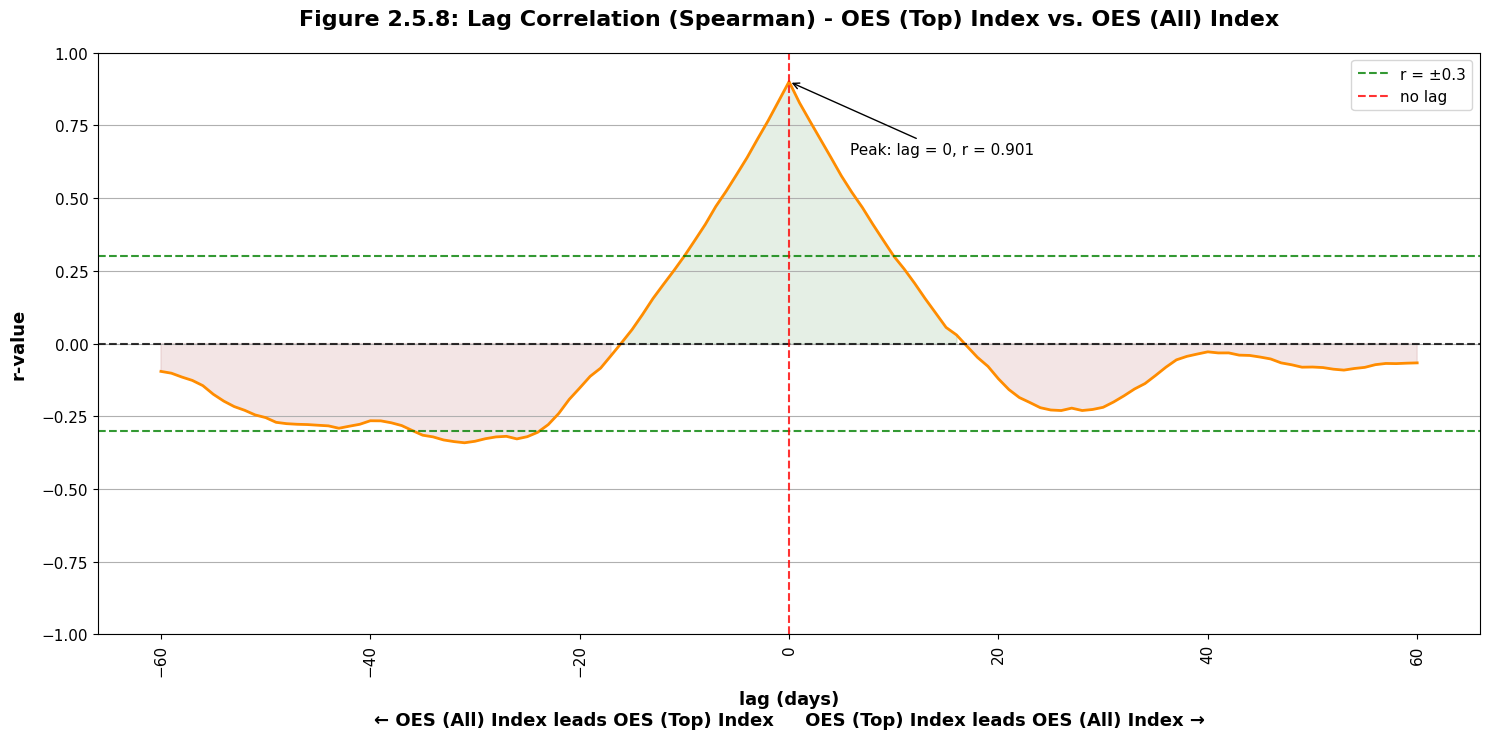

In [60]:
title = f'Figure 2.5.8: Lag Correlation ({corr_method.title()}) ' \
            + '- OES (Top) Index vs. OES (All) Index'


v_lag      = int(x_y1_analysis_df.loc[0, 'lag'])

max_lag \
    = mathx.find_optimal_lag_corr_max_lag \
        (top_median_idx2_series, 
         all_median_idx2_series, 
         var_vecm_lag = v_lag, 
         granger_lag  = g_lag)

max_max_lag = max_lag


matplotlibx.set_lag_corr_xylabels('OES (Top) Index', 'OES (All) Index')

matplotlibx.set_lag_corr_annot_xyoffsets(5.8, -0.25)


matplotlibx.plot_lag_corr_line_chart(top_median_idx2_series, all_median_idx2_series, title, max_lag = max_lag)

## **Section 2.6: Oil & Gas Energy Sector (OES) Indices (%) Comparison**

### **Create DataFrame OES (Top) Index (%) vs. OES (All) Index (%)**

In [61]:
oil_sctr_idxs_pct_df \
    = pd.DataFrame \
        ({'oes_top_index%': top_median_idx_pct_series,
          'oes_all_index%': all_median_idx_pct_series})

logx.log_write_obj(oil_sctr_idxs_df)

In [62]:
title = 'Table 2.6.1: OES (Top) Index (%) vs. OES (All) Index (%)'

fmt_dict \
    = {'oes_top_index%': pandasx.fmt_dict['curr_flt'],
       'oes_all_index%': pandasx.fmt_dict['curr_flt']}

pandasx.rtn_fmt_tbl(oil_sctr_idxs_pct_df, title, hide_idx_bool = False).format(fmt_dict)

,oes_top_index%,oes_all_index%
2020-01-23,$-0.09,$-2.51
2020-01-24,$-0.57,$-3.41
2020-01-27,$-2.12,$-1.83
2020-01-28,$-0.03,$0.29
2020-01-29,$-0.33,$1.03
2020-01-30,$-1.65,$-1.42
2020-01-31,$-2.44,$-2.60
2020-02-03,$-1.30,$-0.37
2020-02-04,$0.01,$1.23
2020-02-05,$2.79,$1.92


### **Display OES (Top) Index (%) vs. OES (All) Index (%) (Pre-Transformations)**

<Figure size 970.8x600 with 0 Axes>

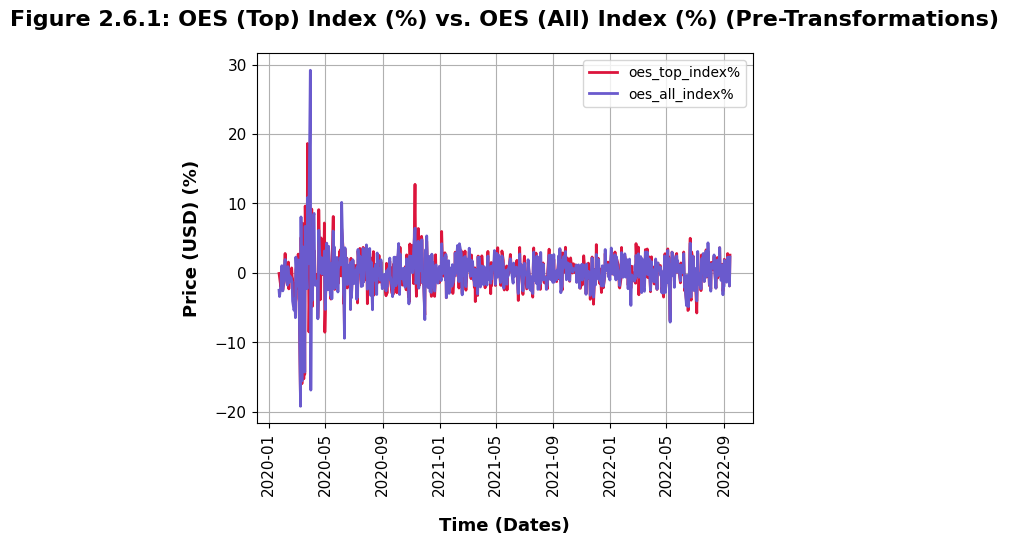

In [63]:
title = 'Figure 2.6.1: OES (Top) Index (%) vs. OES (All) Index (%) (Pre-Transformations)'


matplotlibx.set_line_chart_colors(matplotlibx.stacked_line_chart_colors[7:])

matplotlibx.set_line_chart_title_fontsize(16.0)

matplotlibx.set_line_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_line_chart_xyticks_fontsize(11.0, 11.0)


matplotlibx.line_chart(oil_sctr_idxs_pct_df, title)

### **Transformations for Stationarity - OES (Top) Index (%) vs. OES (All) Index (%)**

In [64]:
trns_pct_df            = mathx.crct_stnry_df(oil_sctr_idxs_pct_df.to_dict(orient = 'series'))

top_median_idx3_series = trns_pct_df['oes_top_index%']

all_median_idx3_series = trns_pct_df['oes_all_index%']

STATIONARY TIME SERIES DETECTED: oes_top_index%.


STATIONARY TIME SERIES DETECTED: oes_all_index%.




### **Display OES (Top) Index (%) vs. OES (All) Index (%) (Post-Transformations)**

<Figure size 970.8x600 with 0 Axes>

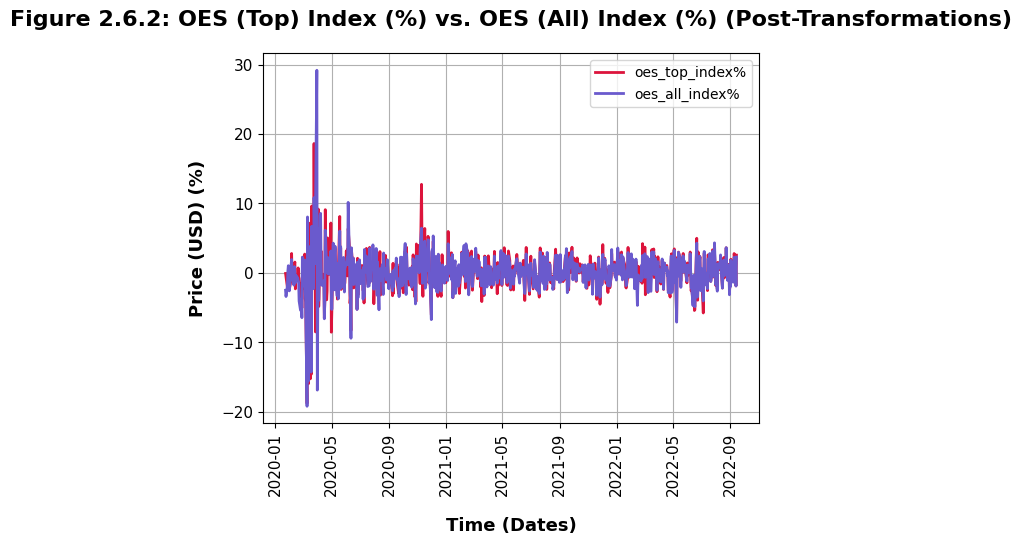

In [65]:
title = 'Figure 2.6.2: OES (Top) Index (%) vs. OES (All) Index (%) (Post-Transformations)'


matplotlibx.set_line_chart_colors(matplotlibx.stacked_line_chart_colors[7:])

matplotlibx.set_line_chart_title_fontsize(16.0)

matplotlibx.set_line_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_line_chart_xyticks_fontsize(11.0, 11.0)


matplotlibx.line_chart(trns_pct_df, title)

### **AIC, Cross-validated R², and Overfitting Score for Polynomial Degree: OES (Top) Index (%) vs. OES (All) Index (%)**

In [66]:
title = 'Table 2.6.2: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree ' \
            + '- OES (Top) Index (%) vs. OES (All) Index (%)'


best_deg, scores_dict, _, results_df \
    = mathx.best_poly_degree \
        (all_median_idx3_series, 
         top_median_idx3_series)

corr_method \
    = mathx.find_opt_corr_method \
        (all_median_idx3_series, 
         top_median_idx3_series)


pandasx.rtn_fmt_tbl(results_df, title) \
    .map(pandasx.highlight_bool_col, subset = ['overfit']) \
    .apply(pandasx.highlight_val_row, col = 'degree', val = best_deg, axis = 1)

degree,train_r2,cv_r2,cv_r2_std,cv_norm,aic,aic_norm,overfit,combined_score
1,0.58,0.64,0.15,1.00,784.66,0.00,False,0.50
2,0.62,0.44,0.53,1.00,723.97,0.21,False,0.61
3,0.66,-2.50,6.45,1.00,655.13,0.45,False,0.73
4,0.66,-48.31,98.07,1.00,656.80,0.45,True,0.72
5,0.66,"-18,029.23","36,059.90",1.00,658.29,0.44,True,0.72
6,0.66,"-126,365.81","252,733.05",1.00,657.19,0.45,True,0.72
7,0.66,"-53,907,228.96","107,814,459.35",1.00,652.29,0.46,True,0.73
8,0.73,"-162,140,679.25","324,281,359.90",1.00,498.59,1.00,True,1.00
9,0.73,"-1,191,833,955.52","2,383,667,912.45",1.00,498.89,1.00,True,1.00
10,0.71,"-11,500,231,479,172.64","23,000,462,958,346.39",0.00,551.35,0.82,True,0.41


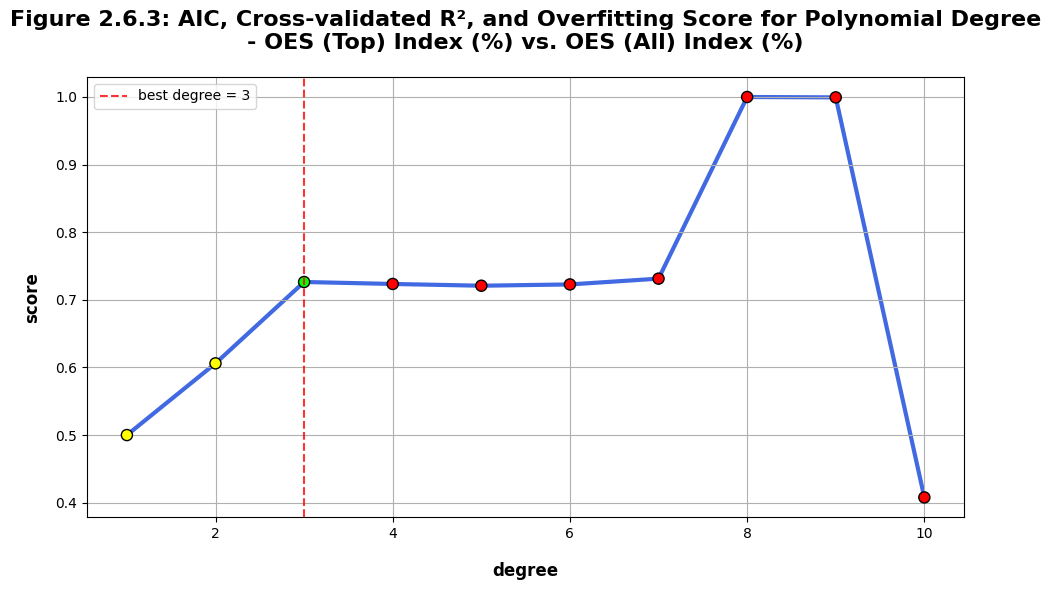

In [67]:
title = 'Figure 2.6.3: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree\n' \
            + '- OES (Top) Index (%) vs. OES (All) Index (%)'


matplotlibx.set_corr_scores_xylabels('degree', 'score')

matplotlibx.set_corr_scores_marker_size(8.0)

matplotlibx.set_lag_corr_method(corr_method)


matplotlibx.plot_corr_scores(scores_dict, title, best_deg)

### **Correlation (Spearman): OES (Top) Index (%) vs. OES (All) Index (%)**

In [68]:
title = f'Table 2.6.3: Correlation ({corr_method.title()}): ' \
            + 'OES (Top) Index (%) vs. OES (All) Index (%)'

pandasx.rtn_fmt_tbl(trns_pct_df.corr(method = corr_method), title, hide_idx_bool = False)

,oes_top_index%,oes_all_index%
oes_top_index%,1.00,0.83
oes_all_index%,0.83,1.00


### **Scatter Plot: OES (Top) Index (%) vs. OES (All) Index (%)**

r-value (pearson):	0.762
r-value (spearman):	0.826
tau (kendall):		0.676

p-value (pearson):	0.000
p-value (spearman):	0.000
p-value (kendall):	0.000




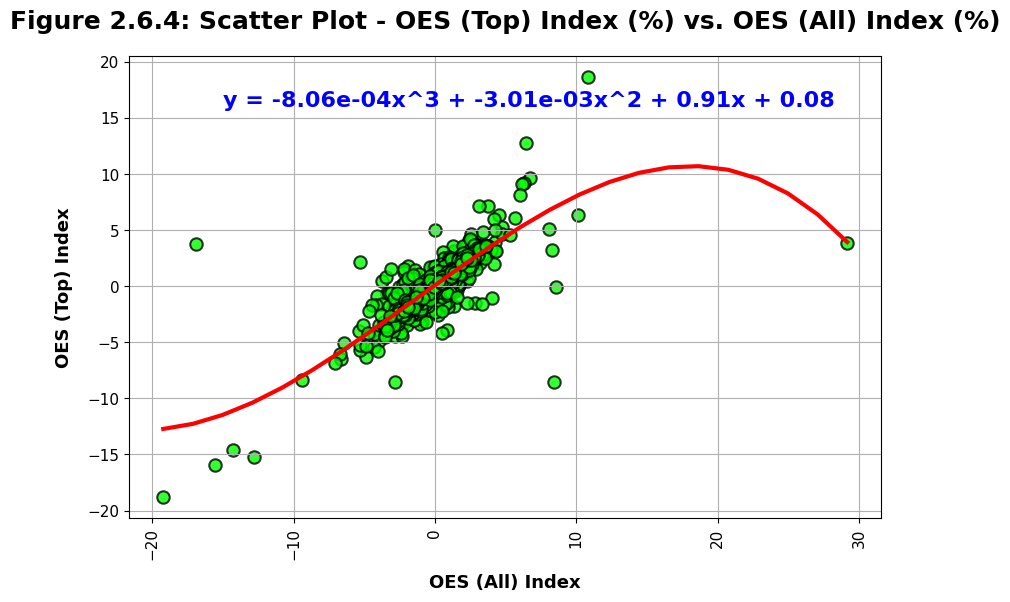

In [69]:
title = 'Figure 2.6.4: Scatter Plot - OES (Top) Index (%) vs. OES (All) Index (%)'


matplotlibx.set_scatterplot_chart_xylabels('OES (All) Index', 'OES (Top) Index')

matplotlibx.set_scatterplot_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_scatterplot_chart_xyticks_fontsize(11.0, 11.0)

matplotlibx.set_scatterplot_chart_title_fontsize(18.0)

matplotlibx.set_regr_eqn_coords(-15.0, 16.0)

matplotlibx.set_regr_degree(best_deg)


matplotlibx.scatterplot_chart([all_median_idx3_series, top_median_idx3_series], title)

### **The Granger Causality Test: OES (Top) Index (%) -> OES (All) Index (%)**

In [70]:
title = 'Table 2.6.4: The Granger Causality Test ' \
            + '- OES (Top) Index (%) -> OES (All) Index (%)'


grngr_mth, _, _ \
    = mathx.find_optimal_granger_method \
        (top_median_idx3_series, 
         all_median_idx3_series)

g_lag, _ \
    = mathx.find_optimal_granger_lag \
        (top_median_idx3_series, 
         all_median_idx3_series, 
         method = grngr_mth)


test_df, best_dict \
    = mathx.granger_causality_test \
        (top_median_idx3_series, 
         all_median_idx3_series, 
         max_lag = g_lag, 
         method  = grngr_mth)


pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
    .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
    .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
    .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,2.044335,0.153245,False,False,False,False,high confidence


### **The Granger Causality Test: OES (All) Index (%) -> OES (Top) Index (%)**

In [71]:
title = 'Table 2.6.5: The Granger Causality Test - OES (All) Index (%) -> OES (Top) Index (%)'

test_df, best_dict \
    = mathx.granger_causality_test \
        (all_median_idx3_series, 
         top_median_idx3_series, 
         max_lag = g_lag, 
         method  = grngr_mth)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,2.741526,0.098245,False,False,False,False,high confidence


### **VAR/VECM Analysis: OES (Top) Index (%) vs. OES (All) Index (%)**

In [72]:
title            = 'VAR/VECM Analysis: top_median_idx_pct_series, all_median_idx_pct_series'


results_dict     = mathx.fit_var_or_vecm(top_median_idx3_series, all_median_idx3_series)

x_y1_analysis_df = results_dict['summary_df']

msg              = results_dict['conclusion']


logx.print_and_log_text('\033[1m' + msg + '\033[0m')

logx.write_to_folder(msg, title)

OES_TOP_INDEX% VS. OES_ALL_INDEX% ANALYSIS

Model selected: VAR.

Series 'x' is stationary (ADF = -8.513740, p = 0.000000).

Series 'y' is stationary (ADF = -7.052672, p = 0.000000).

Trace and max-eigenvalue tests agree. Both series appear stationary at levels — VAR on levels is appropriate.

Recommended lag (BIC): 4.
AIC = 15, BIC = 4, HQIC = 7, FPE = 15.

VAR(4) fitted.
AIC = 3.146827, BIC = 3.268912.
Stability: UNSTABLE — roots outside unit circle; interpret with caution.

IRF (VAR, 30 periods):
A one-SD shock to x produces a positive net response in y.
Peak x→y effect at lag 2 (magnitude: 0.323685).
Cumulative x→y response: 0.496544.

FEVD (VAR, horizon = 20):
x shocks explain 59.42263% of y's forecast variance (substantial influence).
y's own shocks explain 40.57737% of its own variance.



### **Impulse Response Functions (IRF): OES OES (Top) Index (%) vs. OES (All) Index (%)**

In [73]:
title = 'Table 2.6.6: Impulse Response Functions (IRF) ' \
            + f'- OES (Top) Index vs. OES (All) Index'

try:

    test_df = results_dict['irf_result']['irf_df']

    irf_bool = True

    if len(test_df) > 0:

        display \
            (pandasx.rtn_fmt_tbl \
                (test_df, 
                 title, 
                 hide_idx_bool = False, 
                 line_cnt_int = len(test_df)) \
                    .highlight_min(color = 'mistyrose') \
                    .highlight_max(color = 'greenyellow') \
                    .apply(pandasx.highlight_median_col) \
                    .format('{:,.6f}'))

    else:

        irf_bool = False

        logx.write_to_folder \
            ('\nThere is no Impulse Response Function present with VECM model: ' \
                 + 'OES (Top) Index vs. OES (All) Index\n')
    
except:

    irf_bool = False

    logx.write_to_folder \
        ('\nThere is no Impulse Response Function present with VECM model: ' \
             + 'OES (Top) Index vs. OES (All) Index\n')

,x_shock_x_response,x_shock_y_response,y_shock_x_response,y_shock_y_response
period,,,,
0,1.000000,0.000000,0.000000,1.000000
1,-0.125398,-0.005348,0.118135,-0.061818
2,0.131233,0.323685,-0.079162,-0.255146
3,-0.127401,0.033106,0.185729,0.123649
4,0.107645,0.283017,-0.131491,-0.206860
5,0.037747,-0.079285,-0.015811,0.075615
6,-0.017006,-0.079158,0.025433,0.066382
7,0.027675,0.011587,-0.021281,-0.019880
8,-0.039996,-0.019985,0.026820,0.001520


### **Forecast Error Variance Decomposition (FEVD): OES (Top) Index (%) vs. OES (All) Index (%)**

In [74]:
if irf_bool:
    
    title = 'Table 2.6.7: Forecast Error Variance Decomposition (FEVD) ' \
            + '- OES (Top) Index (%) vs. OES (All) Index (%)'

else:

    title = 'Table 2.6.6: Forecast Error Variance Decomposition (FEVD) ' \
            + '- OES (Top) Index (%) vs. OES (All) Index (%)'    

test_df = results_dict['fevd_result']['fevd_df']

pandasx.rtn_fmt_tbl \
    (test_df, 
     title, 
     hide_idx_bool = False, 
     line_cnt_int = len(test_df)) \
        .highlight_min(color = 'mistyrose') \
        .highlight_max(color = 'greenyellow') \
        .apply(pandasx.highlight_median_col) \
        .format('{:,.6f}')

,y_variance_from_x,y_variance_from_y,x_variance_from_x,x_variance_from_y
period,,,,
0,0.605839,0.394161,1.000000,0.000000
1,0.606051,0.393949,0.994468,0.005532
2,0.596884,0.403116,0.992041,0.007959
3,0.599812,0.400188,0.978760,0.021240
4,0.595874,0.404126,0.972236,0.027764
5,0.594801,0.405199,0.972160,0.027840
6,0.594133,0.405867,0.971918,0.028082
7,0.594055,0.405945,0.971751,0.028249
8,0.594183,0.405817,0.971492,0.028508


### **Rolling R, Stability, and CV Score for Rolling Window: OES (Top) Index (%) vs. OES (All) Index (%)**

In [75]:
best_w, _, results_df \
    = mathx.find_optimal_rolling_window \
        (top_median_idx3_series, 
         all_median_idx3_series, 
         method = corr_method)

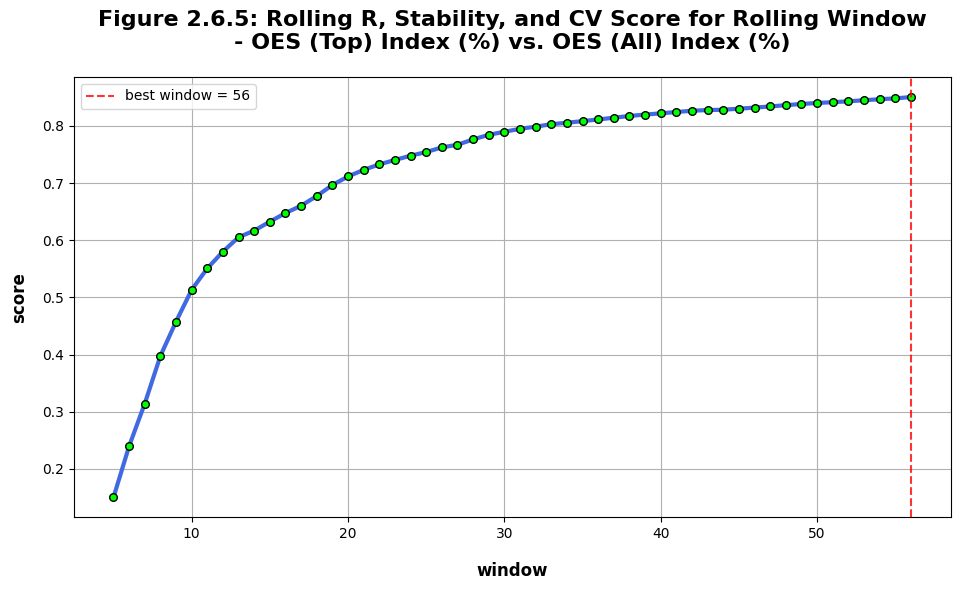

In [76]:
title = 'Figure 2.6.5: Rolling R, Stability, and CV Score for Rolling Window\n' \
            + '- OES (Top) Index (%) vs. OES (All) Index (%)'


matplotlibx.set_corr_scores_xylabels('window', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling R, Stability, and CV Score for Minimum Period: OES (Top) Index vs. OES (All) Index**

In [77]:
best_mp, _, results_df \
    = mathx.find_optimal_min_periods \
        (top_median_idx3_series, 
         all_median_idx3_series, 
         window = best_w, 
         method = corr_method)

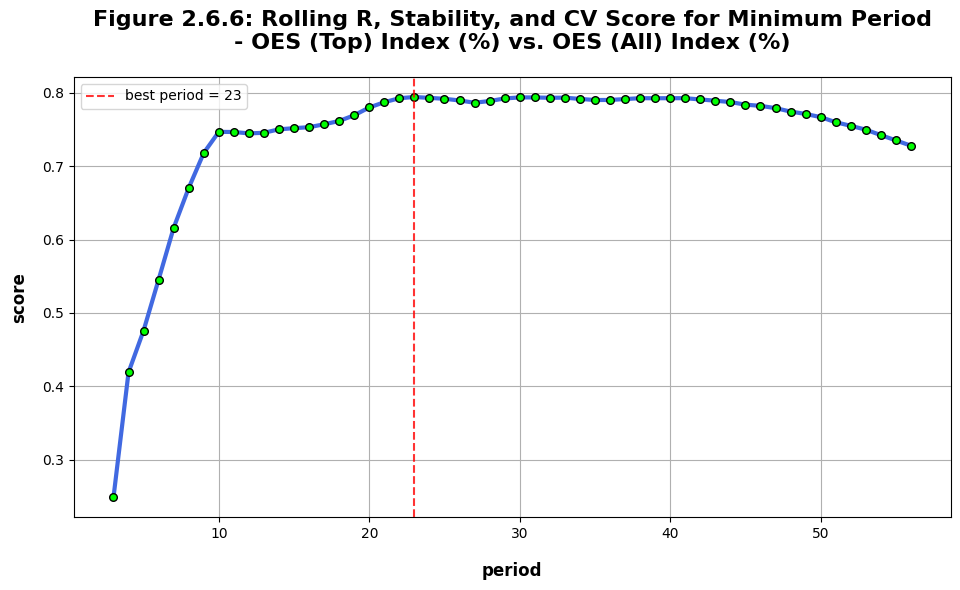

In [78]:
title = 'Figure 2.6.6: Rolling R, Stability, and CV Score for Minimum Period\n' \
            + '- OES (Top) Index (%) vs. OES (All) Index (%)'


matplotlibx.set_corr_scores_xylabels('period', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling Correlation: OES (Top) Index vs. OES (All) Index**

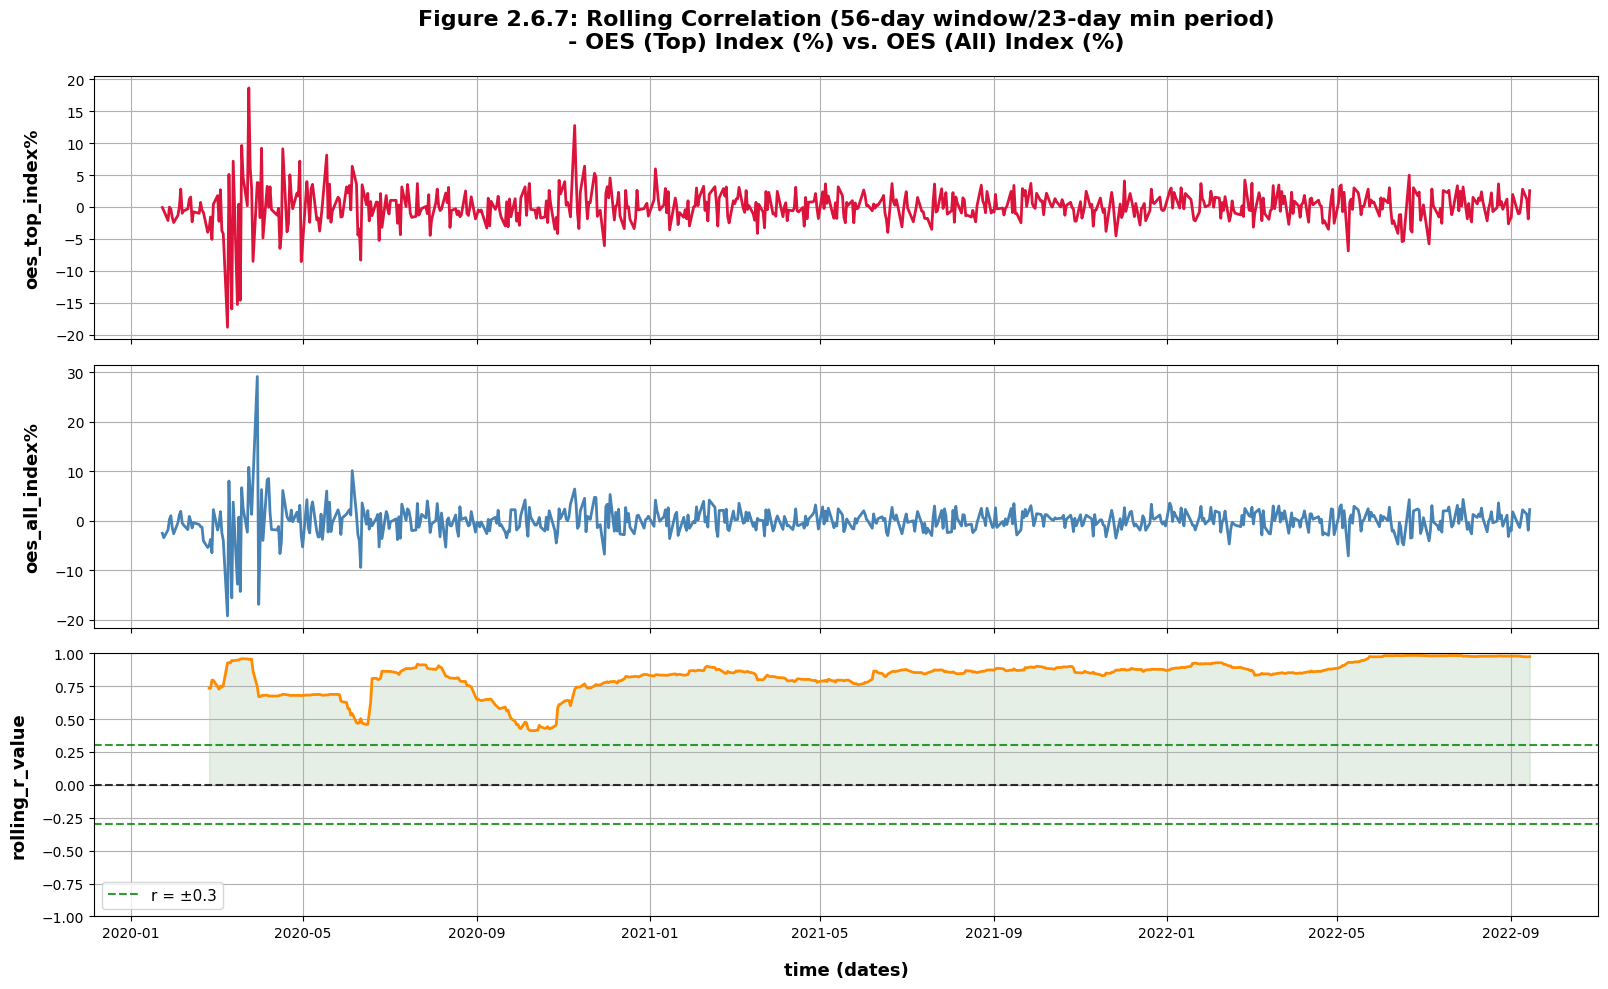

In [79]:
title \
    = f'Figure 2.6.7: Rolling Correlation ({best_w}-day window/{best_mp}' \
        + '-day min period)\n- OES (Top) Index (%) vs. OES (All) Index (%)'


matplotlibx.set_roll_corr_xylabels('time (dates)', [])

matplotlibx.set_roll_corr_w_mp(best_w, best_mp)


matplotlibx.plot_rolling_corr_lines(top_median_idx3_series, all_median_idx3_series, title)

### **Lag Correlation: OES (Top) Index vs. OES (All) Index**

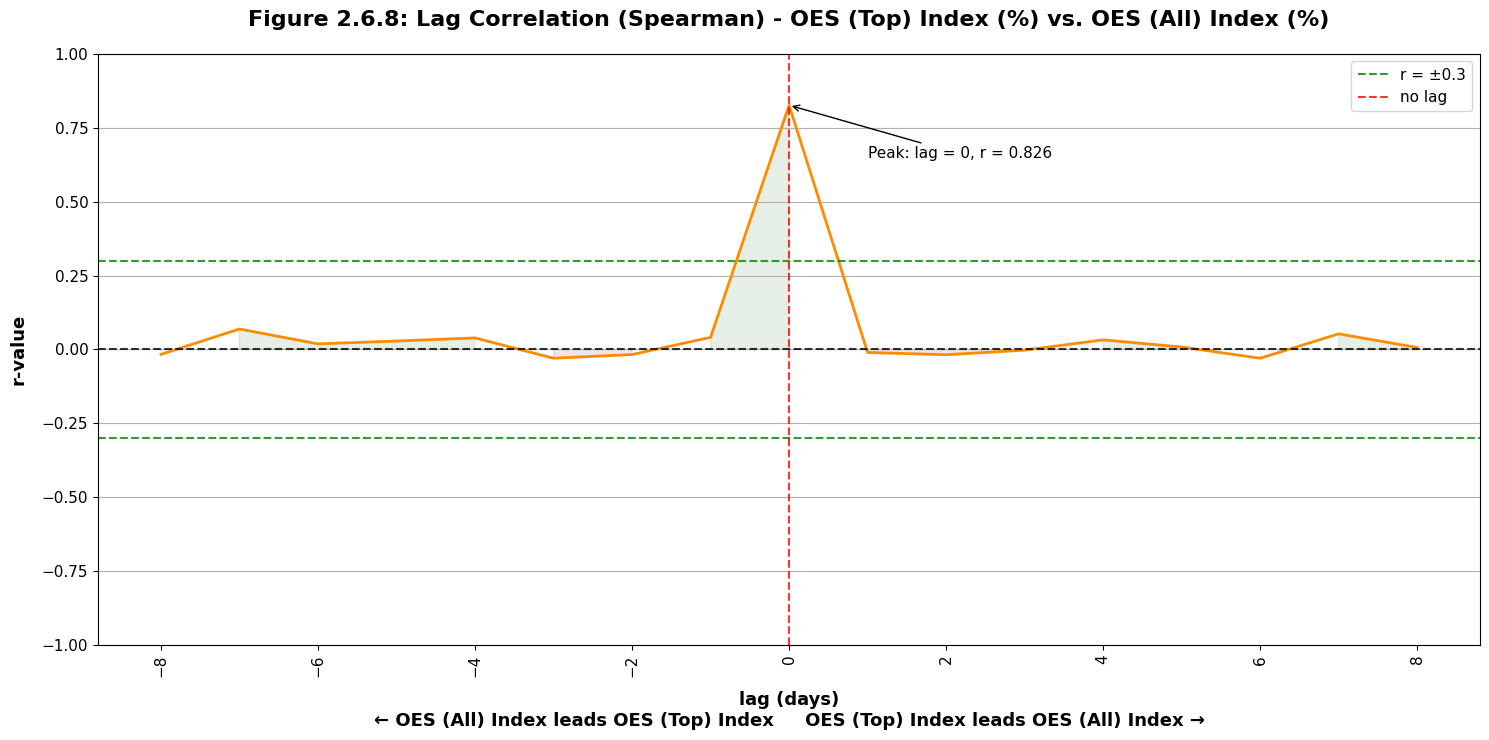

In [80]:
title = f'Figure 2.6.8: Lag Correlation ({corr_method.title()}) ' \
            + '- OES (Top) Index (%) vs. OES (All) Index (%)'


v_lag      = int(x_y1_analysis_df.loc[0, 'lag'])

max_lag \
    = mathx.find_optimal_lag_corr_max_lag \
        (top_median_idx3_series, 
         all_median_idx3_series, 
         var_vecm_lag = v_lag, 
         granger_lag  = g_lag)

max_max_lag = max_lag


matplotlibx.set_lag_corr_xylabels('OES (Top) Index', 'OES (All) Index')

matplotlibx.set_lag_corr_annot_xyoffsets(1.0, -0.18)


matplotlibx.plot_lag_corr_line_chart(top_median_idx3_series, all_median_idx3_series, title, max_lag = max_lag)

## **Section 2.7: Final OES Index Series (Top) to Files**

In [81]:
petrol_df = pd.read_json(assetx.config_dict['file']['petrol'], typ = 'frame')


petrol_df = petrol_df.drop(columns = ['brent_crude_oil'])

petrol_df['oil_top_idx'] = top_median_idx_series.round(2)


petrol_df.to_json(assetx.config_dict['file']['petrol_plus'])

In [82]:
logx.end_program()